### Some Usefull Imports

In [372]:
import pandas as pd
import pandas as pd
import numpy as np
import requests
import yfinance as yf
from io import StringIO
from datetime import datetime


In [373]:
import importlib
import testing2_helper
importlib.reload(testing2_helper)

<module 'testing2_helper' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\testing2_helper.py'>

In [374]:
import importlib
import clean
importlib.reload(clean)


<module 'clean' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\clean.py'>

In [375]:
import importlib
import additional
importlib.reload(additional)

<module 'additional' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\additional.py'>

In [376]:
import importlib
import benchmark
importlib.reload(benchmark)

<module 'benchmark' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\benchmark.py'>

In [377]:
import importlib
import helper_ml
importlib.reload(helper_ml)

<module 'helper_ml' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\helper_ml.py'>

In [378]:
import importlib
import momentum
importlib.reload(momentum)

<module 'momentum' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\momentum.py'>

In [379]:
import importlib
import reversion
importlib.reload(reversion)

<module 'reversion' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\reversion.py'>

In [380]:
import importlib
import volatility
importlib.reload(volatility)

<module 'volatility' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\volatility.py'>

In [381]:
import importlib
import seasonality
importlib.reload(seasonality)

<module 'seasonality' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\seasonality.py'>

In [382]:
import importlib
import Markowitz_helper
importlib.reload(Markowitz_helper)

<module 'Markowitz_helper' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\Markowitz_helper.py'>

In [383]:
import importlib
import risk
importlib.reload(risk)

<module 'risk' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\risk.py'>

In [384]:
import importlib
import MARKOWITZ_traditional
importlib.reload(MARKOWITZ_traditional)

<module 'MARKOWITZ_traditional' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\MARKOWITZ_traditional.py'>

In [385]:
import importlib
import plot
importlib.reload(plot)

<module 'plot' from 'c:\\Users\\Biswajit Kala\\Desktop\\Industry Project\\assignment 3 _testing\\plot.py'>

In [386]:
from testing2_helper import *
from additional import *  
from benchmark import *
from clean import *
from helper_ml import *
from momentum import *
from reversion import *
from seasonality import *
from volatility import *
from Markowitz_helper import *
from risk import *
from MARKOWITZ_traditional import *
from plot import *

### Data Import(csv)

In [387]:
data=pd.read_csv('raw_df.csv')

In [388]:
data.head(2)

,date,symbol,series,prev close,open,high,low,last,close,vwap,volume,turnover,trades,deliverable volume,%deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.0,770.0,1050.0,770.0,959.0,962.9,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.9,984.0,990.0,874.0,885.0,893.9,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172


In [389]:
len(set(data['symbol']))

65

In [390]:
df=create_close_price_matrix(data)

In [391]:
df.head(2)

symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJAUTOFIN,BAJFINANCE,BHARTI,BHARTIARTL,BPCL,...,TISCO,TITAN,ULTRACEMCO,UNIPHOS,UPL,UTIBANK,VEDL,WIPRO,ZEEL,ZEETELE
date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,381.65,NaN,NaN,NaN,50.75,NaN,NaN,NaN,399.25,...,152.45,155.7,NaN,NaN,NaN,26.70,NaN,2724.20,NaN,1179.95
2000-01-04,NaN,385.55,NaN,NaN,NaN,48.10,NaN,NaN,NaN,370.50,...,150.80,147.4,NaN,NaN,NaN,26.85,NaN,2942.15,NaN,1260.65


In [392]:
df.tail(2)

symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJAUTOFIN,BAJFINANCE,BHARTI,BHARTIARTL,BPCL,...,TISCO,TITAN,ULTRACEMCO,UNIPHOS,UPL,UTIBANK,VEDL,WIPRO,ZEEL,ZEETELE
date,,,,,,,,,,,,,,,,,,,,,
2021-04-29,746.75,2613.45,719.4,3836.45,11176.55,NaN,5484.85,NaN,540.85,419.55,...,NaN,1506.80,6382.45,NaN,615.8,NaN,255.05,489.85,186.55,NaN
2021-04-30,730.05,2536.40,714.9,3833.75,11041.65,NaN,5451.90,NaN,536.75,421.80,...,NaN,1491.65,6278.95,NaN,606.9,NaN,257.25,492.75,185.60,NaN


In [393]:
## Change the symbol name as Stock
df.index.name = 'Stock'


#### I want stocks which have atleast 16 years of data avialable from lastdate 2021-4-30 (30 stocks)

In [394]:
df16,stocklist_16=stocks_with_min_history(df,16,252) ## We have 252 Trading days .

In [395]:
len(stocklist_16)

30

In [396]:
stocklist_16

['ASIANPAINT',
 'BPCL',
 'BRITANNIA',
 'CIPLA',
 'DRREDDY',
 'EICHERMOT',
 'GAIL',
 'GRASIM',
 'HCLTECH',
 'HDFC',
 'HDFCBANK',
 'ICICIBANK',
 'INDUSINDBK',
 'IOC',
 'ITC',
 'KOTAKBANK',
 'LT',
 'M&M',
 'MARUTI',
 'NTPC',
 'ONGC',
 'RELIANCE',
 'SBIN',
 'SHREECEM',
 'SUNPHARMA',
 'TATAMOTORS',
 'TCS',
 'TITAN',
 'ULTRACEMCO',
 'WIPRO']

In [397]:
len(df16.columns)# df16 keep only those stocks as columns which have atleast 16 years of data avialable in the csv file we imported

30

### Data Cleaning

In [398]:
nse_stock_data_d=clean.fully_clean_stock_data_1(df16)

In [399]:
full_date_range1 = pd.date_range(start="2000-01-03", end="2021-04-30", freq='D')

In [400]:
nse_stock_data=clean.fully_clean_stock_data(nse_stock_data_d, full_date_range1)

In [401]:
nse_stock_data.index

DatetimeIndex(['2000-01-03', '2000-01-04', '2000-01-05', '2000-01-06',
               '2000-01-07', '2000-01-08', '2000-01-09', '2000-01-10',
               '2000-01-11', '2000-01-12',
               ...
               '2021-04-21', '2021-04-22', '2021-04-23', '2021-04-24',
               '2021-04-25', '2021-04-26', '2021-04-27', '2021-04-28',
               '2021-04-29', '2021-04-30'],
              dtype='datetime64[ns]', length=7789, freq='D')

In [402]:
nse_stock_data.to_csv("NSE_stock_data.csv", index=True, date_format="%Y-%m-%d")

### Count how many valid (non-NaN) dates are available for each stock

#### Histogram — shows distribution of count of valid dates

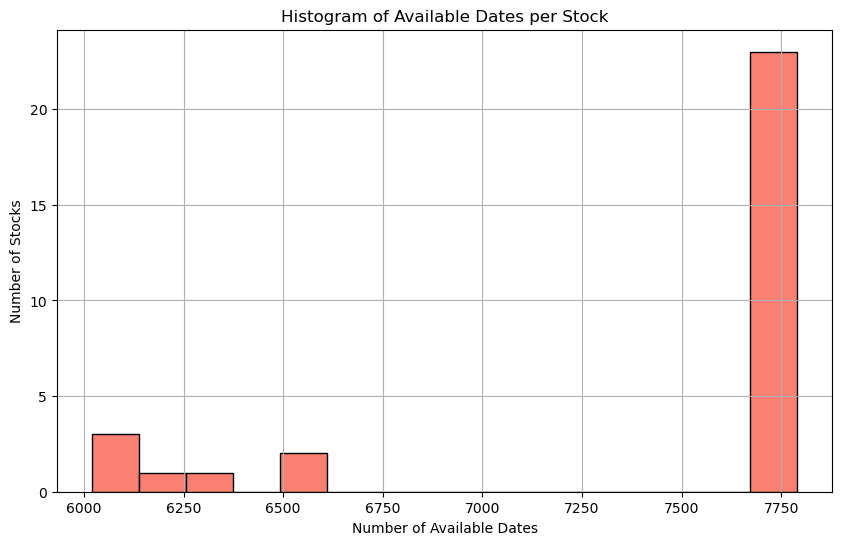

In [403]:
import matplotlib.pyplot as plt
valid_counts=nse_stock_data.notna().sum()
#Histogram — shows distribution of count of valid dates
plt.figure(figsize=(10, 6))
plt.hist(valid_counts, bins=15, color='salmon', edgecolor='black')
plt.xlabel('Number of Available Dates')
plt.ylabel('Number of Stocks')
plt.title('Histogram of Available Dates per Stock')
plt.grid(True)
plt.show()

### Return Calculation

In [404]:
nse_stock_data.index = pd.to_datetime(nse_stock_data.index)

# Get real month-end trading prices
monthly_adj_close = (
    nse_stock_data
    .groupby(nse_stock_data.index.to_period("M"))
    .tail(1)
)

# Monthly returns
monthly_simple_returns = monthly_adj_close.pct_change()
monthly_log_returns = np.log(1 + monthly_simple_returns)

In [405]:
nse_stock_data.index = pd.to_datetime(nse_stock_data.index)

# 1. Rebalance at month-end (take month-end prices) not percentage in fraction
monthly_adj_close_full_50= nse_stock_data.resample('M').last()

# 2. Compute Percentage Return
return_df_monthly=additional.calculate_returns(nse_stock_data,rebalance='ME', periods=1)#"M"  # month-end, "MS"  # month-start, "BM"  # business month-end, "BMS"  # business month-start


# 3. Compute log returns
monthly_log_returns_full_50 = np.log(monthly_adj_close_full_50 / monthly_adj_close_full_50.shift(1))

# 3. Simple returns
monthly_simple_returns_full_50 = (
    (monthly_adj_close_full_50 / monthly_adj_close_full_50.shift(1)) - 1
)

C:\Users\Biswajit Kala\AppData\Local\Temp\ipykernel_18444\1708739830.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_adj_close_full_50= nse_stock_data.resample('M').last()


### Feature Engineering

momentum and reversion

In [406]:
momentum_df = momentum.calculate_12_1_momentum(nse_stock_data, resample='ME')
momentum_reversion = momentum.calculate_m_momentum(nse_stock_data, 1, resample='ME')

seasonality

In [407]:
seasonality_3 = calculate_return_signals(return_df_monthly, 3, rebalance='ME')
seasonality_5 = calculate_return_signals(return_df_monthly, 5, rebalance='ME')

In [408]:
seasonality_3 = convert_signals(seasonality_3, 2)
seasonality_5 = convert_signals(seasonality_5, 3)

c:\Users\Biswajit Kala\Desktop\Industry Project\assignment 3 _testing\helper_ml.py:90: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  converted_df = seasonality_df.applymap(convert_list)


 volatility

In [409]:
vol_df = calculate_volatility(return_df_monthly, 1, resample='ME')
vol_df = vol_df.rename(columns={'Ticker':'Stock'})

In [410]:
vol_df.index.name = 'Stock'
vol_df = vol_df.reset_index()


In [411]:
vol_df

,Stock,2000-12-31 00:00:00,2001-01-31 00:00:00,2001-02-28 00:00:00,2001-03-31 00:00:00,2001-04-30 00:00:00,2001-05-31 00:00:00,2001-06-30 00:00:00,2001-07-31 00:00:00,2001-08-31 00:00:00,...,2020-06-30 00:00:00,2020-07-31 00:00:00,2020-08-31 00:00:00,2020-09-30 00:00:00,2020-10-31 00:00:00,2020-11-30 00:00:00,2020-12-31 00:00:00,2021-01-31 00:00:00,2021-02-28 00:00:00,2021-03-31 00:00:00
0,ASIANPAINT,15.957737,15.234235,14.656915,14.912770,14.746790,14.737162,14.197304,7.333559,5.614704,...,4.977901,5.530105,5.113023,5.901693,5.443052,8.480684,9.774641,10.043533,9.846704,9.898462
1,BPCL,22.127825,21.375803,21.523888,18.919300,18.380858,18.295611,18.162546,18.276989,18.309086,...,14.861904,14.904905,12.066529,11.311895,11.535722,11.575371,11.449732,12.380778,9.366547,8.341018
2,BRITANNIA,13.270275,12.200580,12.363476,10.680671,9.104244,9.136742,6.950586,6.792324,7.294384,...,8.095030,8.282947,8.069467,8.161990,7.897164,7.922189,7.881680,7.623100,7.008606,5.482244
3,CIPLA,14.915933,15.251681,15.248079,14.192047,13.441952,13.203806,12.186081,12.401854,11.550530,...,13.881589,13.377009,12.644521,12.792774,12.835777,12.903461,12.462159,11.928849,11.951642,6.259631
4,DRREDDY,10.958466,10.172296,10.087206,8.585771,11.224197,11.671007,10.789649,10.247343,9.951942,...,8.628325,9.043991,10.290393,10.822172,10.985610,10.836045,11.849613,11.698812,11.683741,9.999297
5,EICHERMOT,11.085848,10.160417,11.918826,11.737185,11.812715,11.743492,11.503250,11.369150,10.754979,...,14.045977,30.293069,30.149553,28.450636,29.595832,29.618030,29.858881,29.585895,29.114188,28.820602
6,GAIL,4.416064,2.422141,0.000000,0.000000,0.000000,0.000000,0.024036,1.922465,3.233946,...,12.573673,12.553830,12.601209,12.506845,14.193639,15.350327,15.340883,14.928020,11.898285,10.207165
7,GRASIM,15.853771,15.125156,16.408068,16.344636,15.202775,15.651690,15.122583,15.806540,14.266089,...,12.082864,11.928881,12.262502,12.241454,12.694851,12.530188,12.929688,12.282575,5.669515,6.786122
8,HCLTECH,20.848028,20.666536,22.694547,22.899557,22.798226,23.213297,22.949898,19.621350,21.541580,...,19.828084,19.696060,20.400078,20.299529,20.292426,13.416418,13.641497,13.020148,10.692419,10.135458
9,HDFC,11.100219,10.010525,10.450116,9.042178,9.836285,9.087379,8.642041,8.669300,7.743399,...,11.502110,11.520984,11.335481,11.540406,12.432479,12.929349,13.152969,12.810993,9.738766,8.959183


In [412]:
vol_df.index.name   # check this


Melting volatility df dataframe

In [413]:
vol_df.reset_index(inplace=True)  

vol_melted = vol_df.melt(
    id_vars='Stock',
    var_name='Date',
    value_name='Volatility'
)

vol_melted.rename(columns={'index': 'Stock'}, inplace=True)

In [414]:
vol_melted['Date'] = pd.to_datetime(vol_melted['Date'], errors='coerce')
vol_melted= vol_melted.dropna(subset=['Date'])

C:\Users\Biswajit Kala\AppData\Local\Temp\ipykernel_18444\752394800.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  vol_melted['Date'] = pd.to_datetime(vol_melted['Date'], errors='coerce')


compute bin returns

In [415]:
bin_returns = convert_df_values(return_df_monthly, 0, 0)

c:\Users\Biswajit Kala\Desktop\Industry Project\assignment 3 _testing\helper_ml.py:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(convert_value)


In [416]:
bin_returns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, ASIANPAINT to WIPRO
Columns: 256 entries, 2000-01-31 to 2021-04-30
Freq: ME
dtypes: int64(256)
memory usage: 61.3+ KB


###  merging all the engineered features together after melting each one

In [417]:
# Melt each DataFrame
bin_returns_melted = melt_df_new_1(bin_returns, 'bin_Return')
returns_melted = melt_df_new_1(return_df_monthly, 'Return')
momentum_reversal_melted = melt_df_new_1(momentum_reversion, 'Momentum_Reversal')
momentum_12_1_melted = melt_df_new_1(momentum_df, 'Momentum_12_1')
seasonality_3_melted = melt_df(seasonality_3, 'Seasonality_3')
seasonality_5_melted = melt_df(seasonality_5, 'Seasonality_5')
merged_df = bin_returns_melted
merged_df = merged_df.merge(returns_melted, on=['Stock', 'Date'])
merged_df = merged_df.merge(momentum_reversal_melted, on=['Stock', 'Date'])
merged_df = merged_df.merge(momentum_12_1_melted, on=['Stock', 'Date'])
merged_df = merged_df.merge(vol_melted, on=['Stock', 'Date'])
merged_df = merged_df.merge(seasonality_3_melted, on=['Stock', 'Date'])
merged_df = merged_df.merge(seasonality_5_melted, on=['Stock', 'Date'])


 Convert 'Date' column to datetime

In [418]:

merged_df['Date'] = pd.to_datetime(merged_df['Date'])

In [419]:
merged_df.head()

,Stock,Date,bin_Return,Return,Momentum_Reversal,Momentum_12_1,Volatility,Seasonality_3,Seasonality_5
0,ASIANPAINT,2001-01-31,1,0.339495,-4.174950,-39.923996,15.234235,-1,-1
1,BPCL,2001-01-31,1,13.727390,27.093596,-68.131868,21.375803,-1,-1
2,BRITANNIA,2001-01-31,-1,-8.005768,-0.604437,7.452293,12.200580,-1,-1
3,CIPLA,2001-01-31,-1,-10.494733,7.749413,-11.009292,15.251681,-1,-1
4,DRREDDY,2001-01-31,1,2.056348,2.055466,-6.742025,10.172296,-1,-1


# Add lagged terms

In [420]:
training_df=add_lagged_features(merged_df)

keep only those rows where bin returns nonzero

In [421]:
training_df = training_df[training_df.bin_Return != 0].reset_index(drop=True)

In [422]:
df=training_df

fixing data range in terms of time

In [423]:
df = df[
    (df['Date'] > pd.Timestamp('2005-10-31')) &
    (df['Date'] < pd.Timestamp('2021-04-30'))
].reset_index(drop=True)


In [424]:
training_df=df

In [425]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5547 entries, 0 to 5546
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Stock              5547 non-null   object        
 1   Date               5547 non-null   datetime64[ns]
 2   bin_Return         5547 non-null   int64         
 3   Return             5547 non-null   float64       
 4   Momentum_Reversal  5547 non-null   float64       
 5   Momentum_12_1      5547 non-null   float64       
 6   Volatility         5547 non-null   float64       
 7   Seasonality_3      5547 non-null   int64         
 8   Seasonality_5      5547 non-null   int64         
 9   Lag_2              5547 non-null   float64       
 10  Lag_3              5547 non-null   float64       
 11  Lag_4              5547 non-null   float64       
 12  Lag_5              5547 non-null   float64       
 13  Lag_6              5547 non-null   float64       
 14  Lag_7   

In [426]:
merged_df1=training_df

### handleing missing values

There is no missing values


In [427]:
df_clean=training_df

#### drop stock name

In [428]:
filtered_df = df_clean.drop(['Stock'], axis=1).reset_index(drop=True)

# EDA

In [429]:
num_cols = filtered_df.select_dtypes(include = ['float64']).columns
num_cols

Index(['Return', 'Momentum_Reversal', 'Momentum_12_1', 'Volatility', 'Lag_2',
       'Lag_3', 'Lag_4', 'Lag_5', 'Lag_6', 'Lag_7', 'Lag_8', 'Lag_9', 'Lag_10',
       'Lag_11', 'Lag_12'],
      dtype='object')

In [430]:
cat_cols = df.select_dtypes(include = ['int64']).columns
cat_cols

Index(['bin_Return', 'Seasonality_3', 'Seasonality_5'], dtype='object')

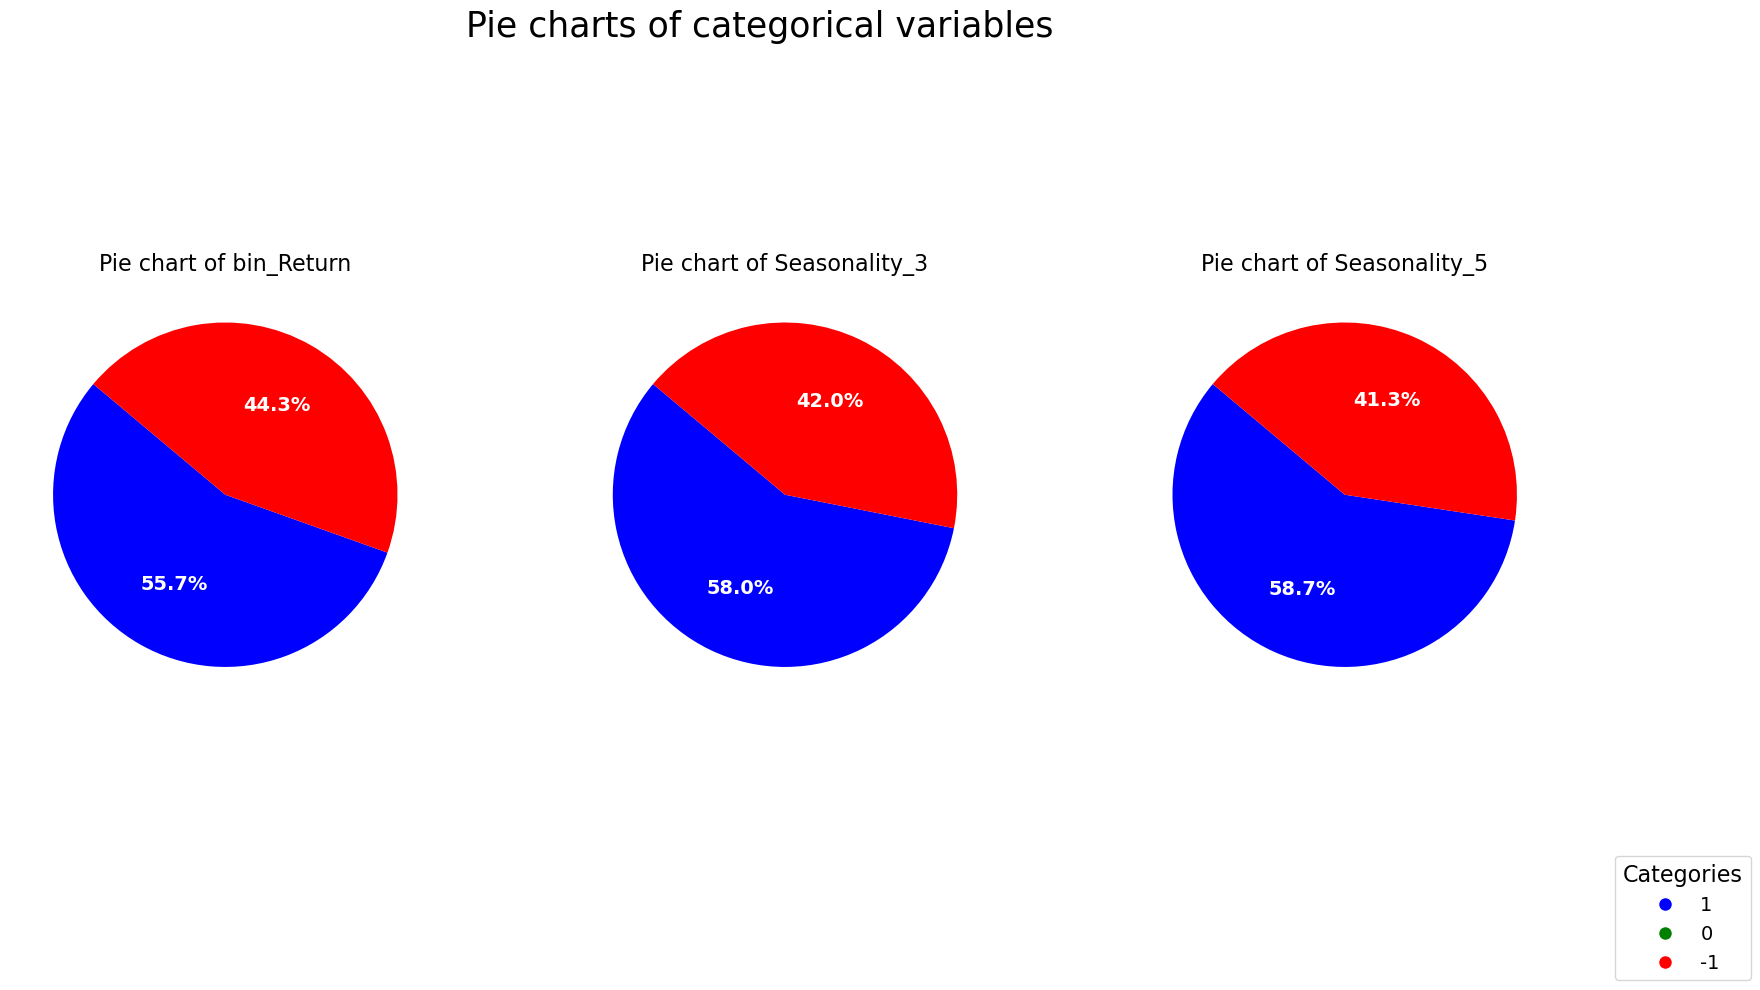

In [431]:
import matplotlib.pyplot as plt
import numpy as np

# Define color mapping for the categories
color_map = {1: 'blue', 0: 'green', -1: 'red'}

# Initialize the plot
fig, axs = plt.subplots(1, len(cat_cols), figsize=(20, 10))
axs = np.atleast_1d(axs)  # Ensure axs is iterable even if len(cat_cols) == 1
plt.subplots_adjust(wspace=0.3, hspace=0.3)

for ax, col in zip(axs, cat_cols):
    value_counts = df[col].value_counts()
    percentages = value_counts / value_counts.sum() * 100
    wedges, texts, autotexts = ax.pie(
        percentages, labels=None, autopct='%1.1f%%', startangle=140,
        colors=[color_map[key] for key in percentages.index],
        textprops=dict(color="w", fontsize=14, fontweight='bold')
    )
    ax.set_title(f'Pie chart of {col}', fontsize=16)
    for autotext in autotexts:
        autotext.set_fontsize(14)
        autotext.set_fontweight('bold')

# Create a legend on the bottom right
labels = ['1', '0', '-1']
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[int(label)], markersize=10)
    for label in labels
]
fig.legend(handles, labels, title='Categories', loc='lower right', fontsize=14, title_fontsize=16)

plt.suptitle('Pie charts of categorical variables', size=25)
plt.show()


### classes in the categorical columns are slidely imbalanced... don't worry we will appy xgboost

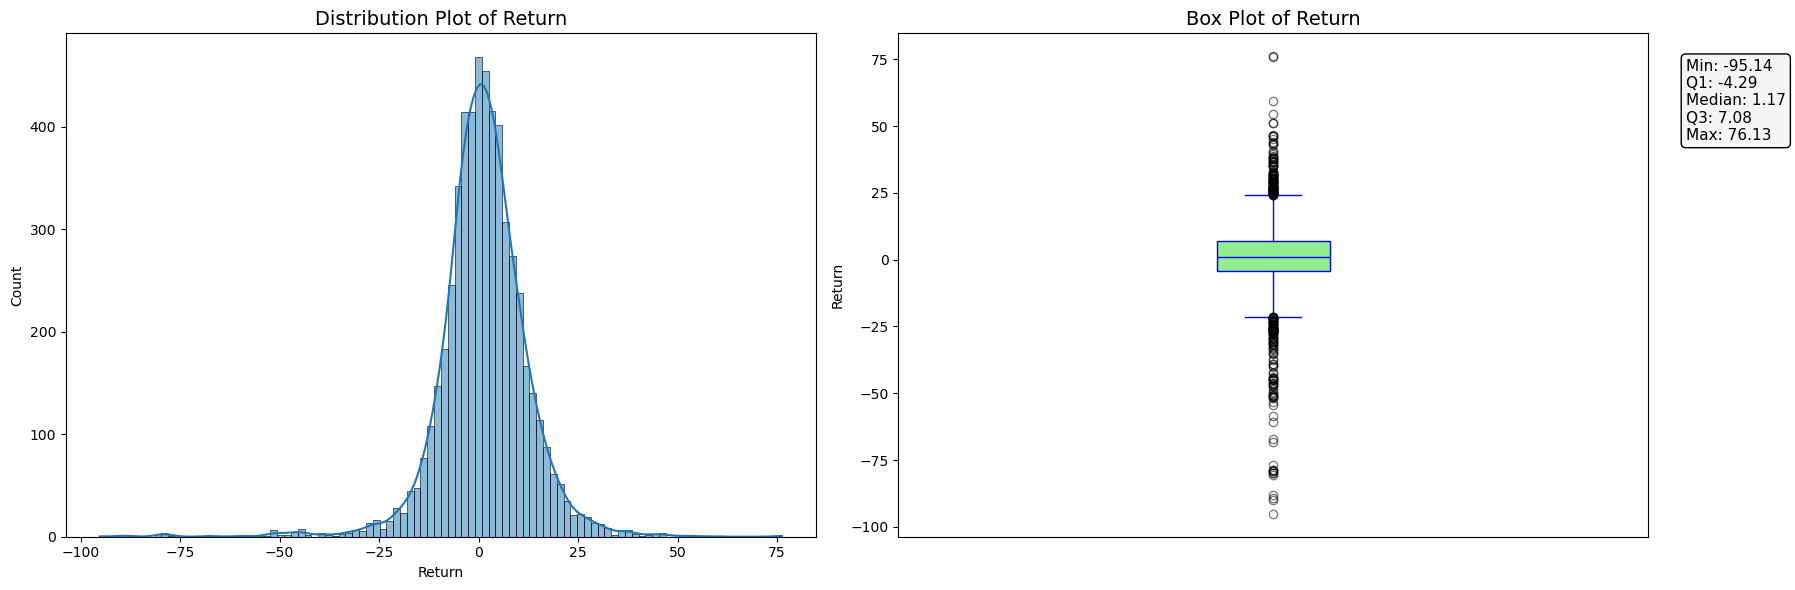

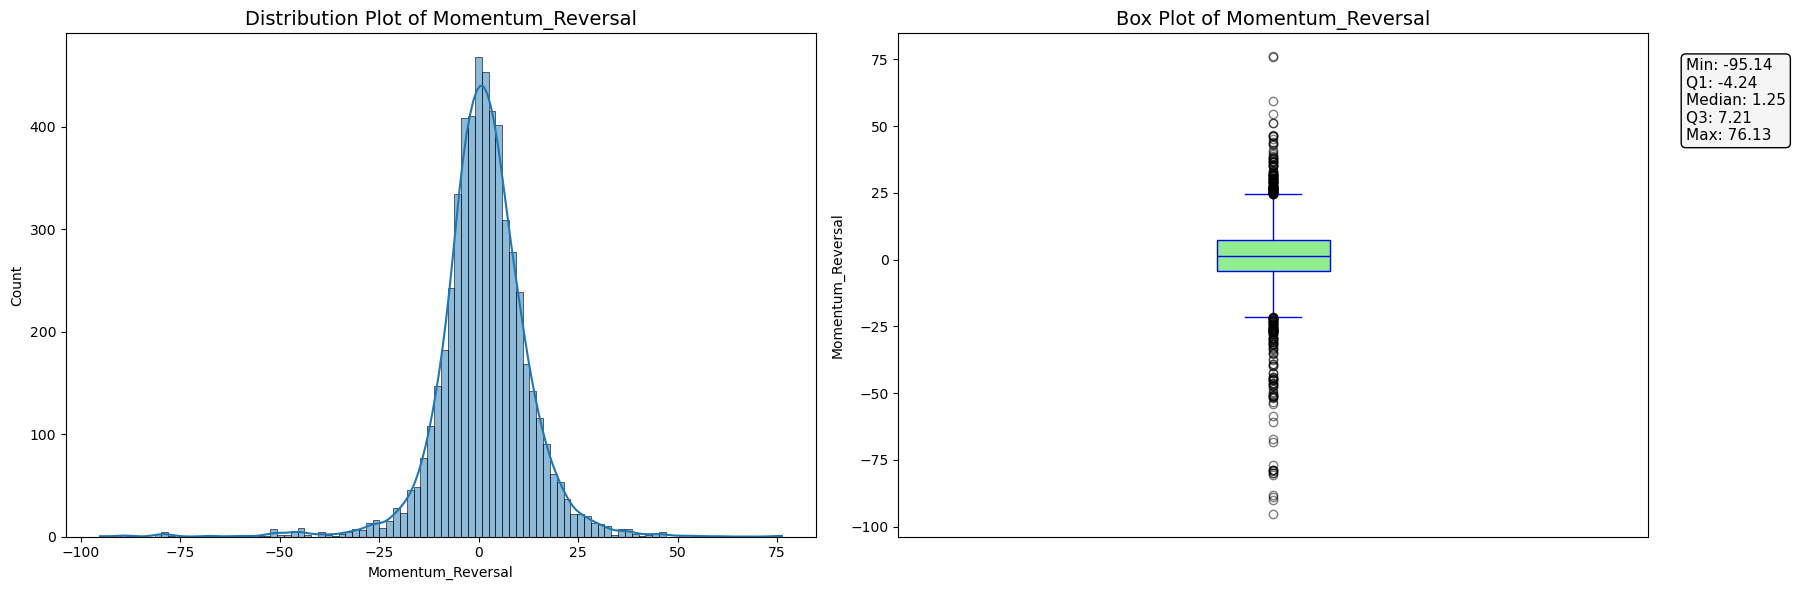

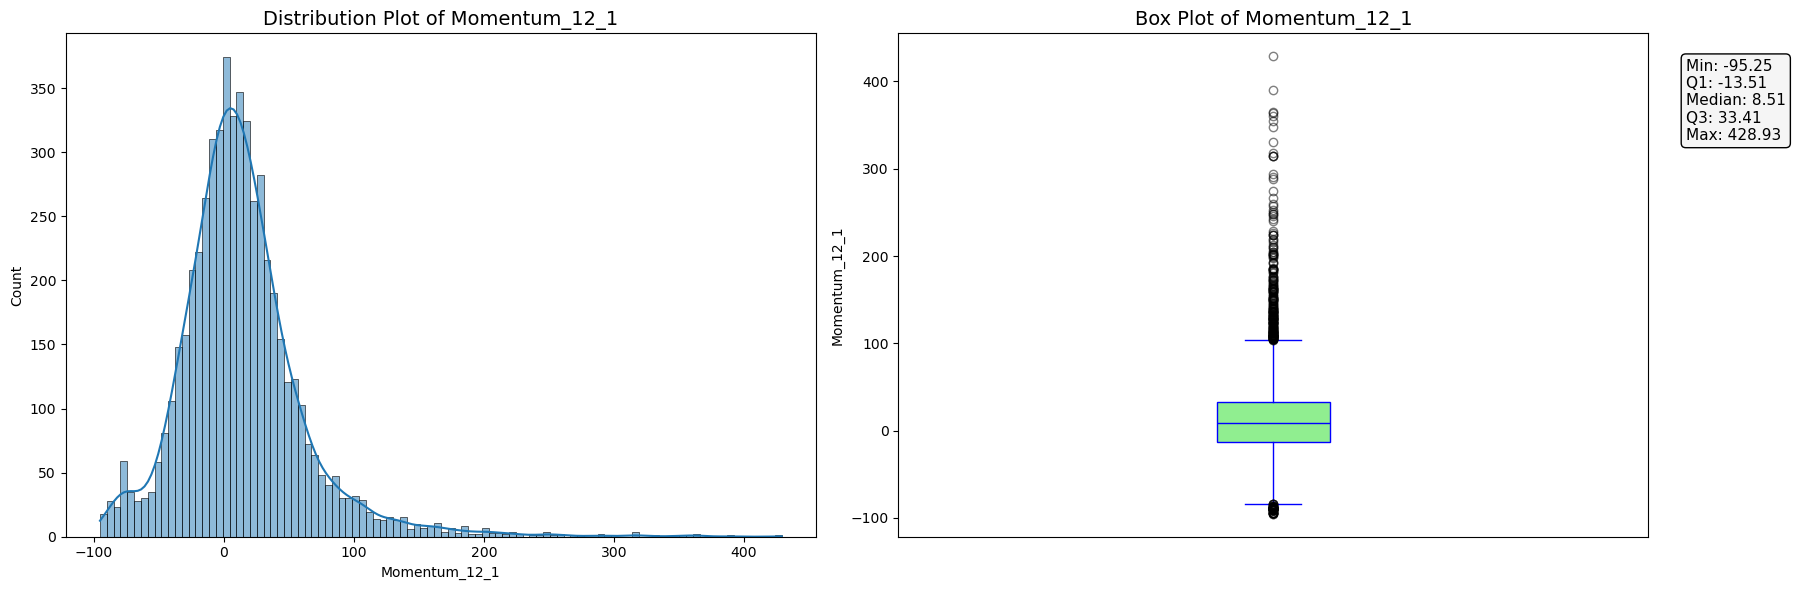

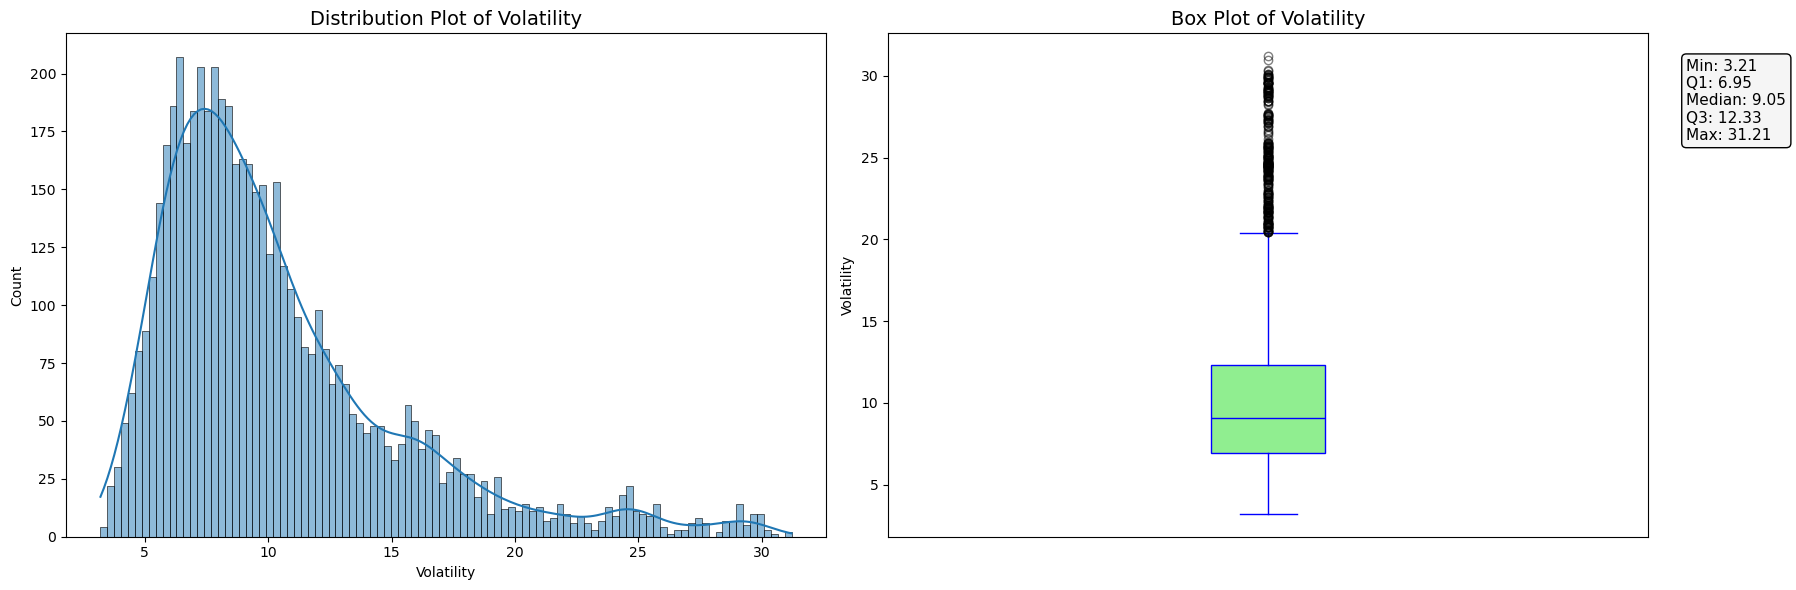

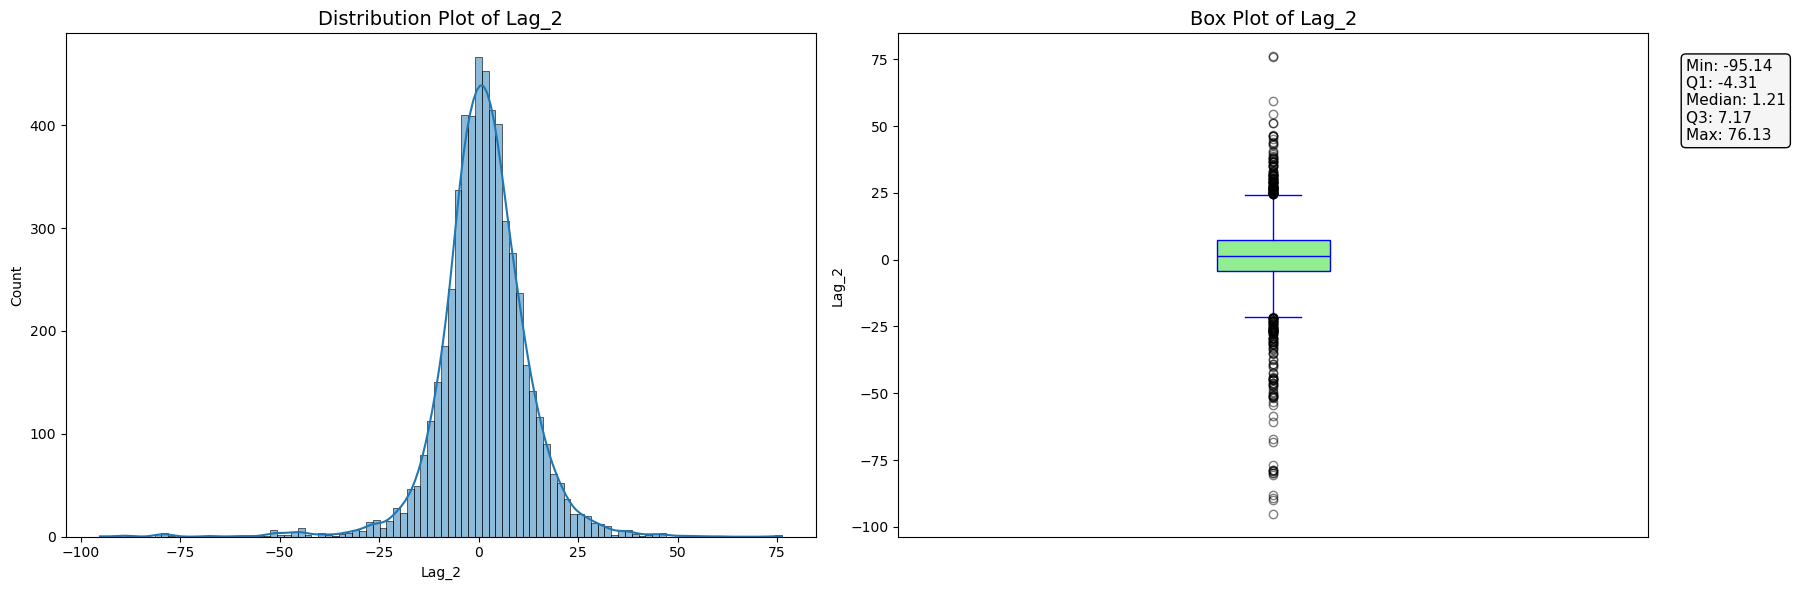

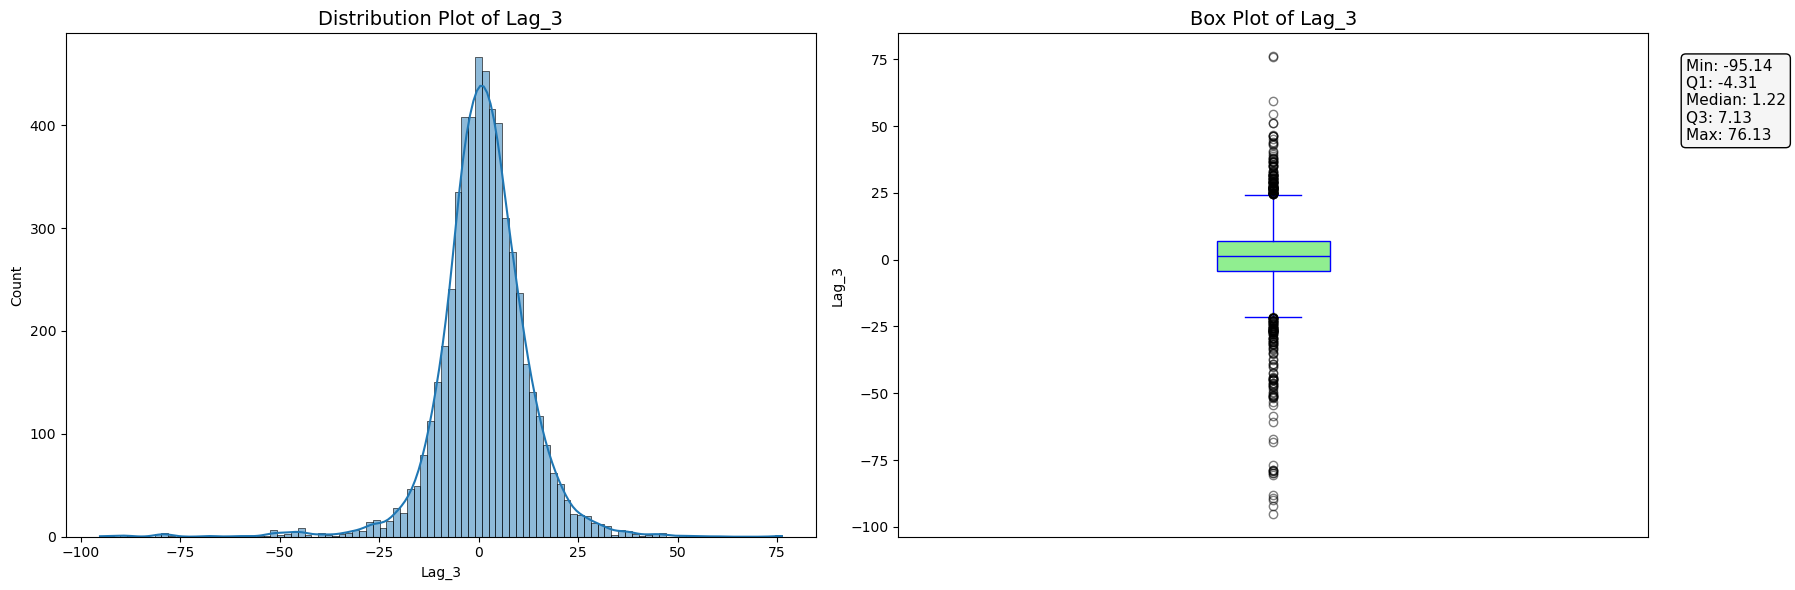

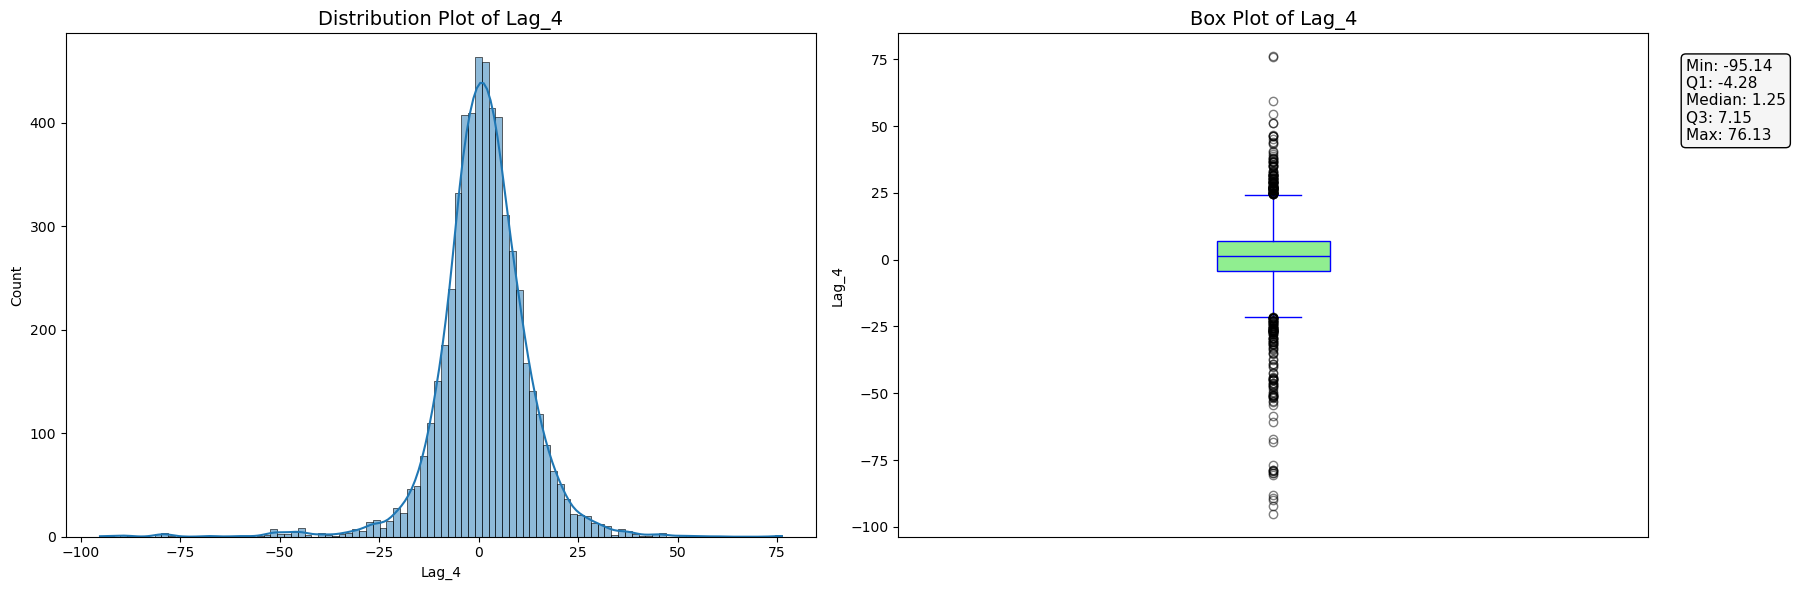

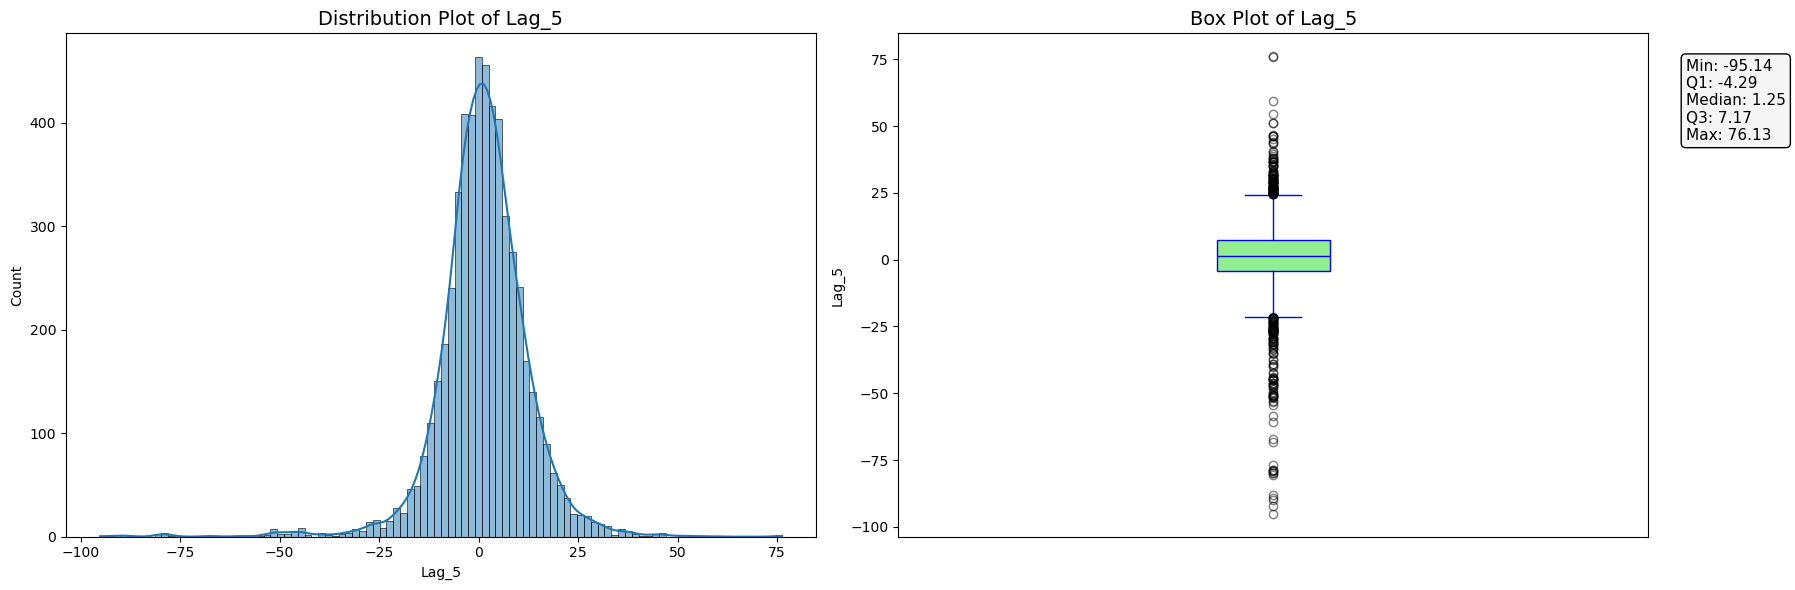

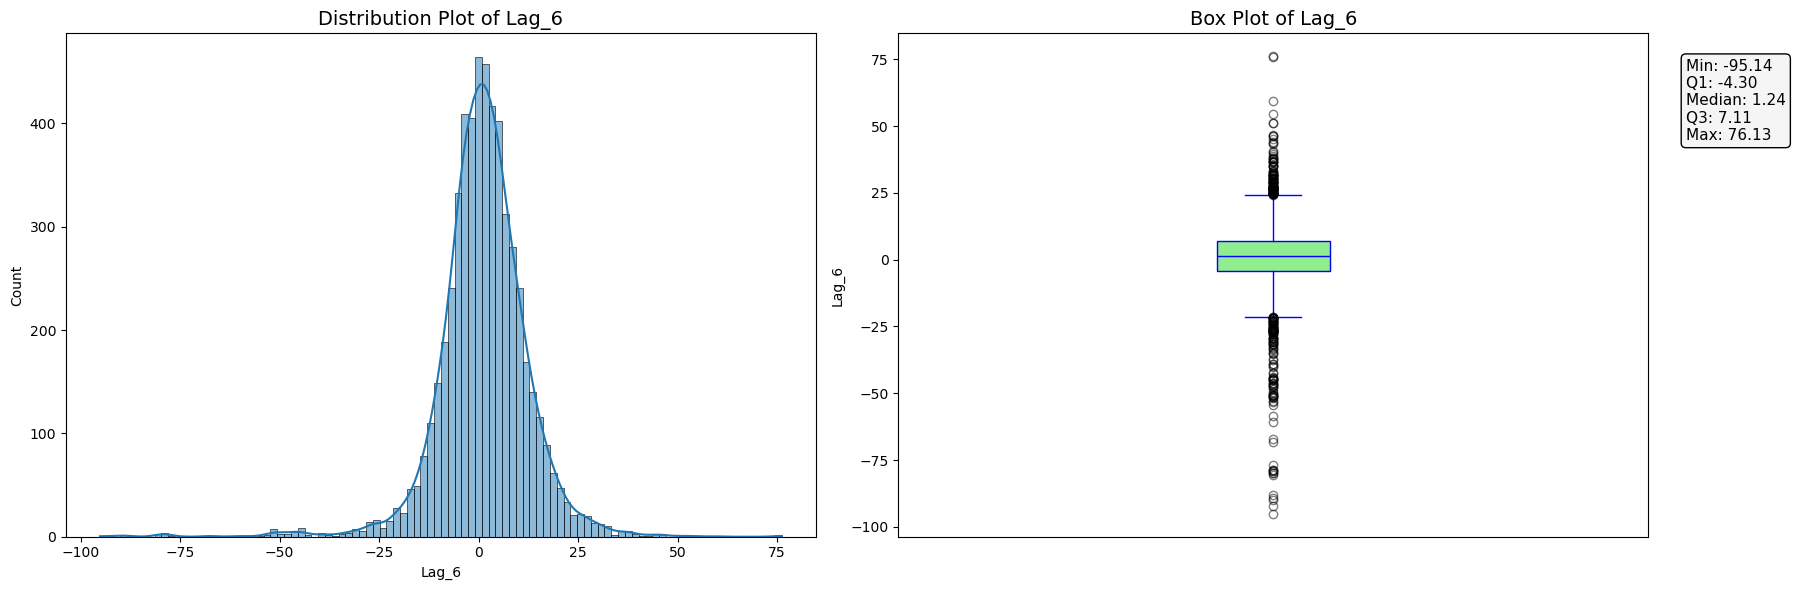

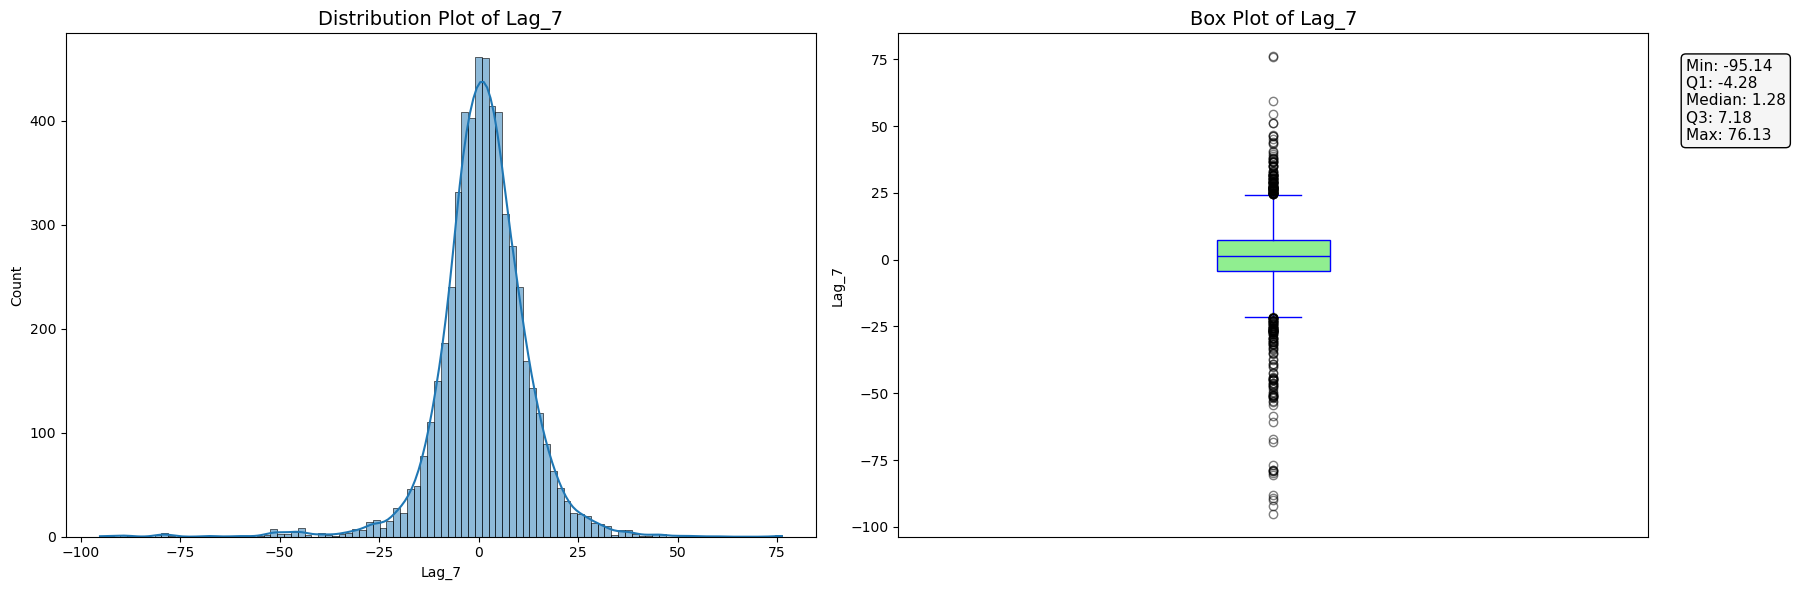

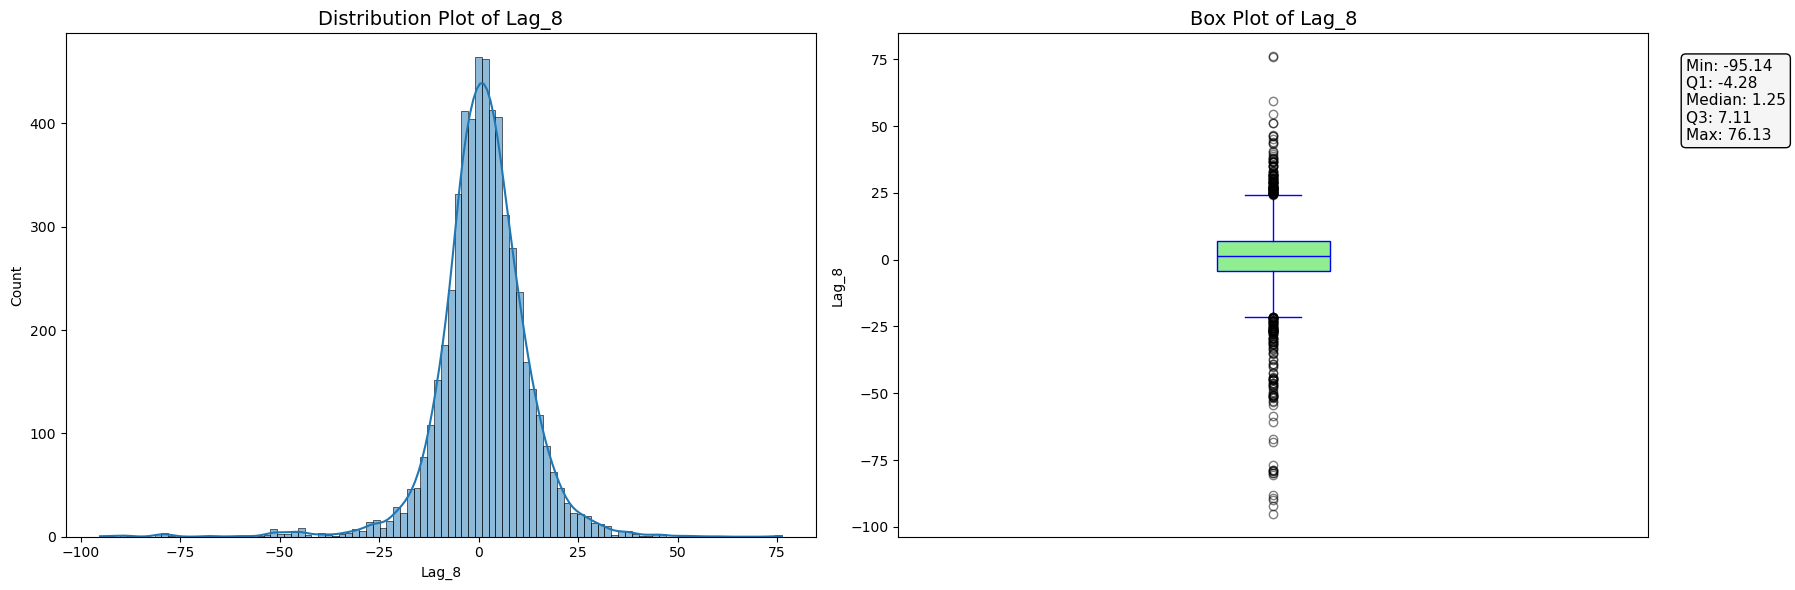

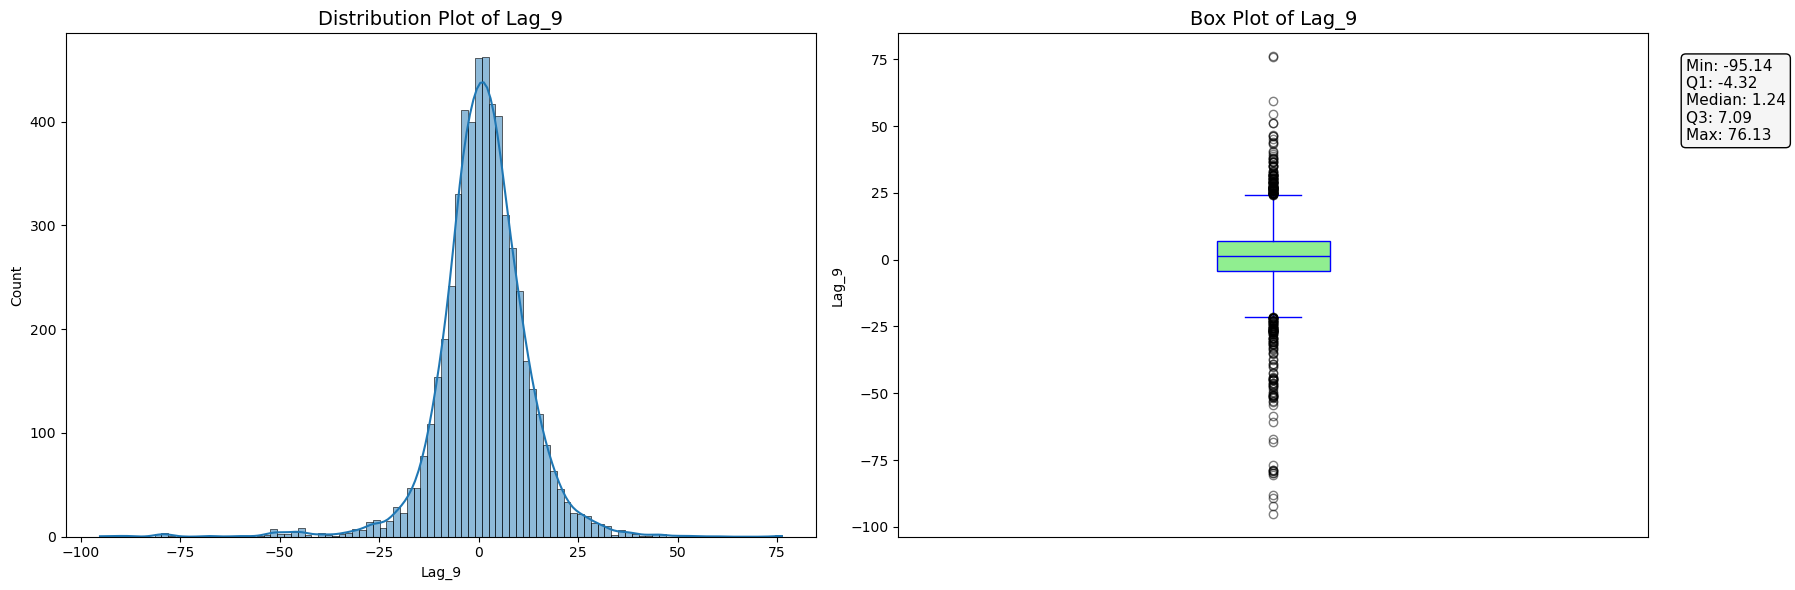

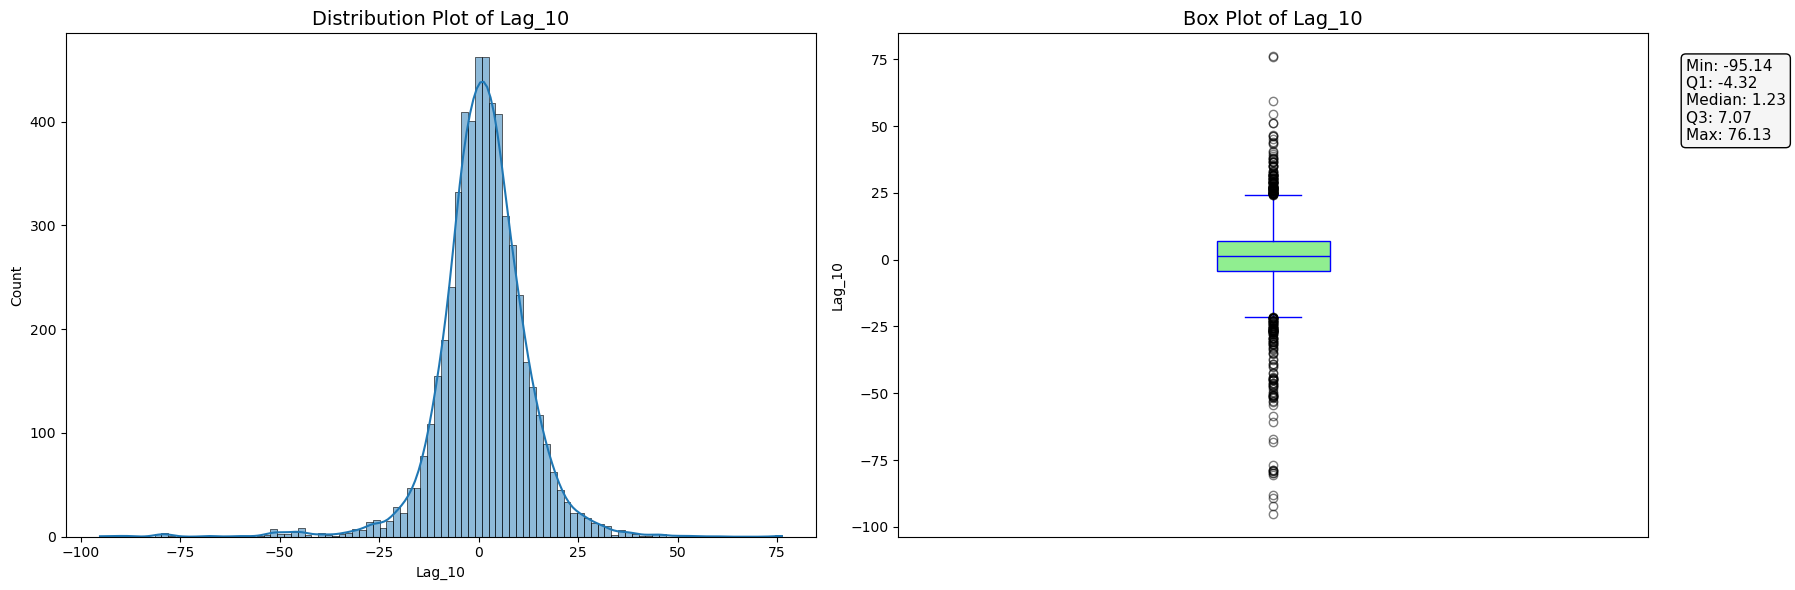

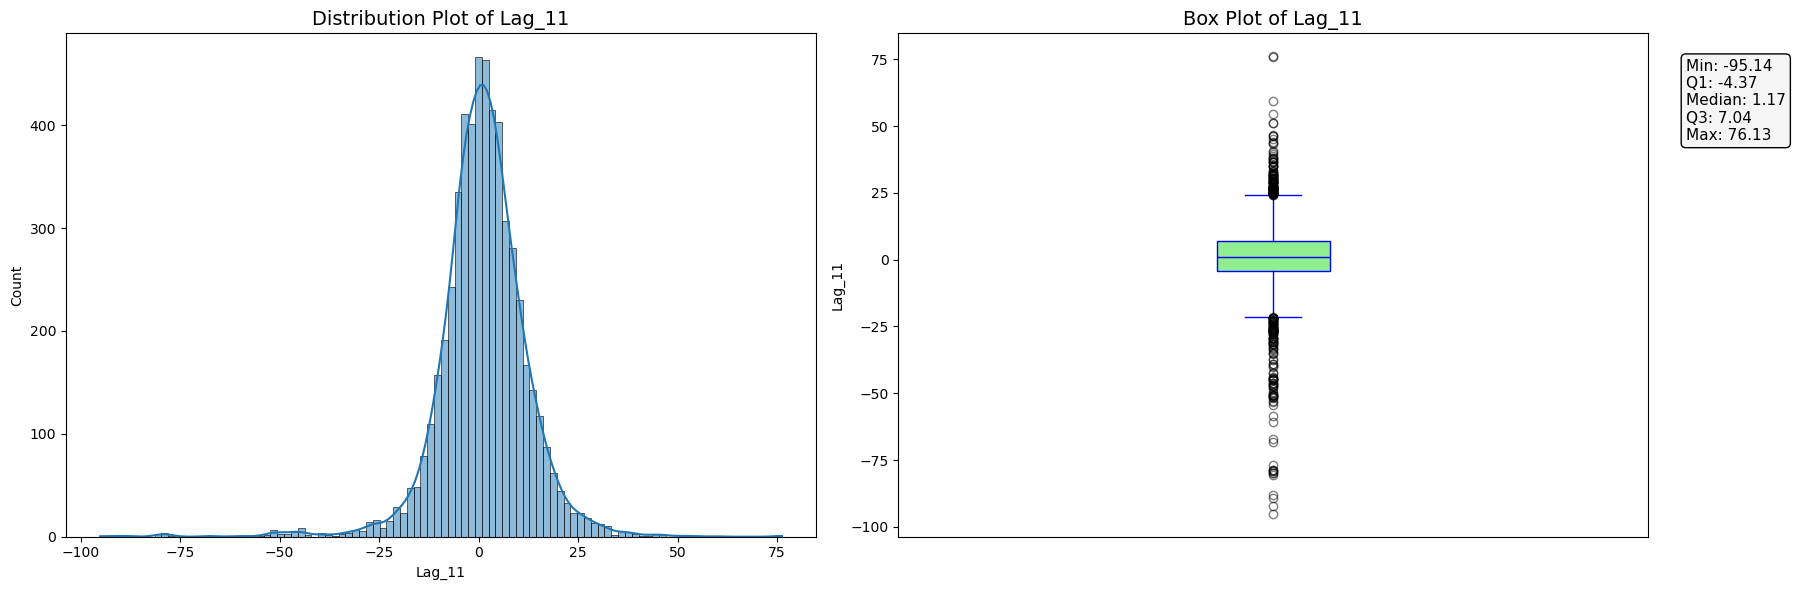

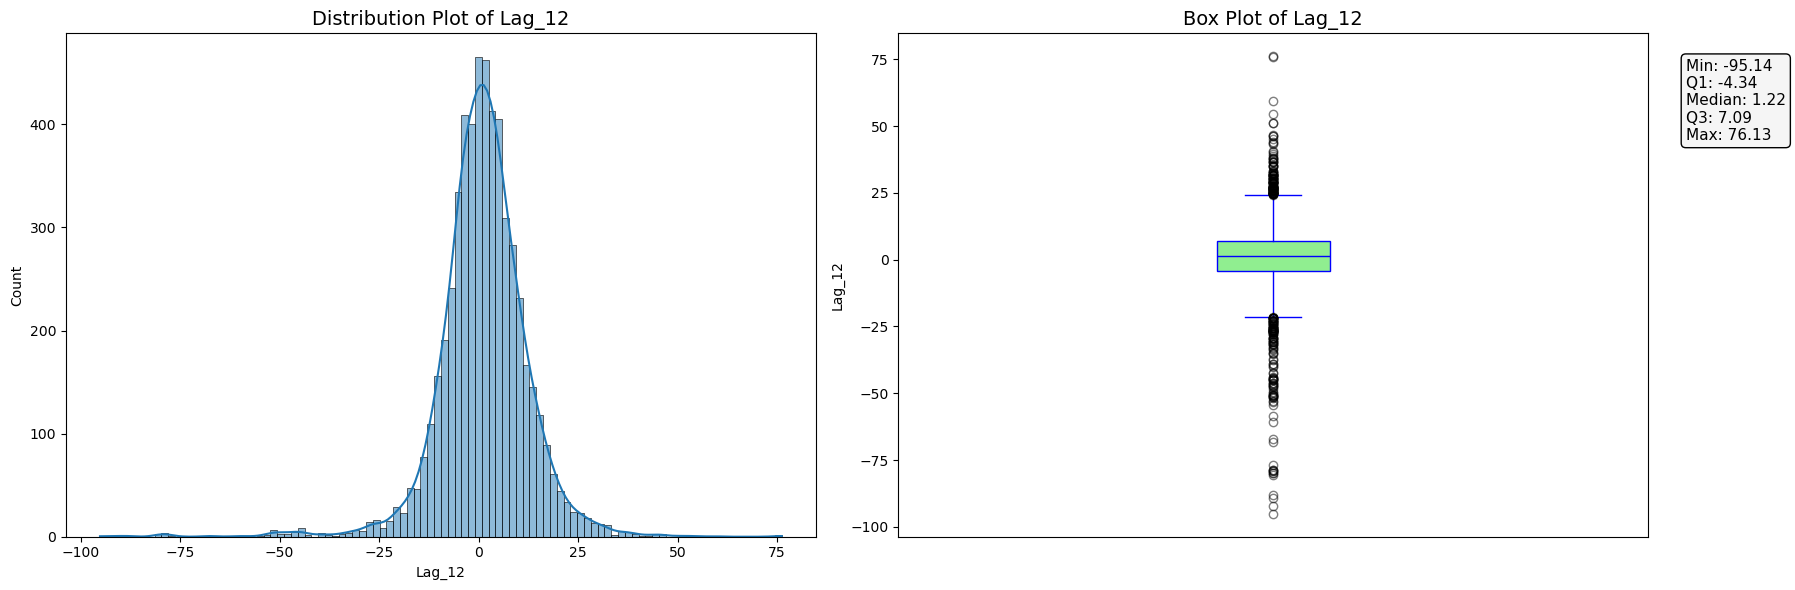

In [432]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

for col in num_cols:
    series = df[col].dropna()
    stats = {
        'Min': np.min(series),
        'Q1': np.percentile(series, 25),
        'Median': np.median(series),
        'Q3': np.percentile(series, 75),
        'Max': np.max(series)
    }

    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # Histogram
    sns.histplot(series, kde=True, ax=ax[0], bins=100)
    ax[0].set_title(f'Distribution Plot of {col}', fontsize=14)
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Count")

    # Boxplot
    ax[1].boxplot(series, vert=True, patch_artist=True,
                  boxprops=dict(facecolor='lightgreen', color='blue'),
                  medianprops=dict(color='blue'),
                  whiskerprops=dict(color='blue'),
                  capprops=dict(color='blue'),
                  flierprops=dict(marker='o', color='black', alpha=0.5))

    ax[1].set_title(f'Box Plot of {col}', fontsize=14)
    ax[1].set_ylabel(col)
    ax[1].set_xticks([])

    # Create legend-style annotation in top-right
    textstr = '\n'.join([f'{key}: {val:.2f}' for key, val in stats.items()])
    ax[1].text(1.05, 0.95, textstr,
               transform=ax[1].transAxes,
               fontsize=11,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='whitesmoke', edgecolor='black'))

    plt.tight_layout()
    plt.show()


## distribution of the numerical columns are more or less normal

corelation heatmap

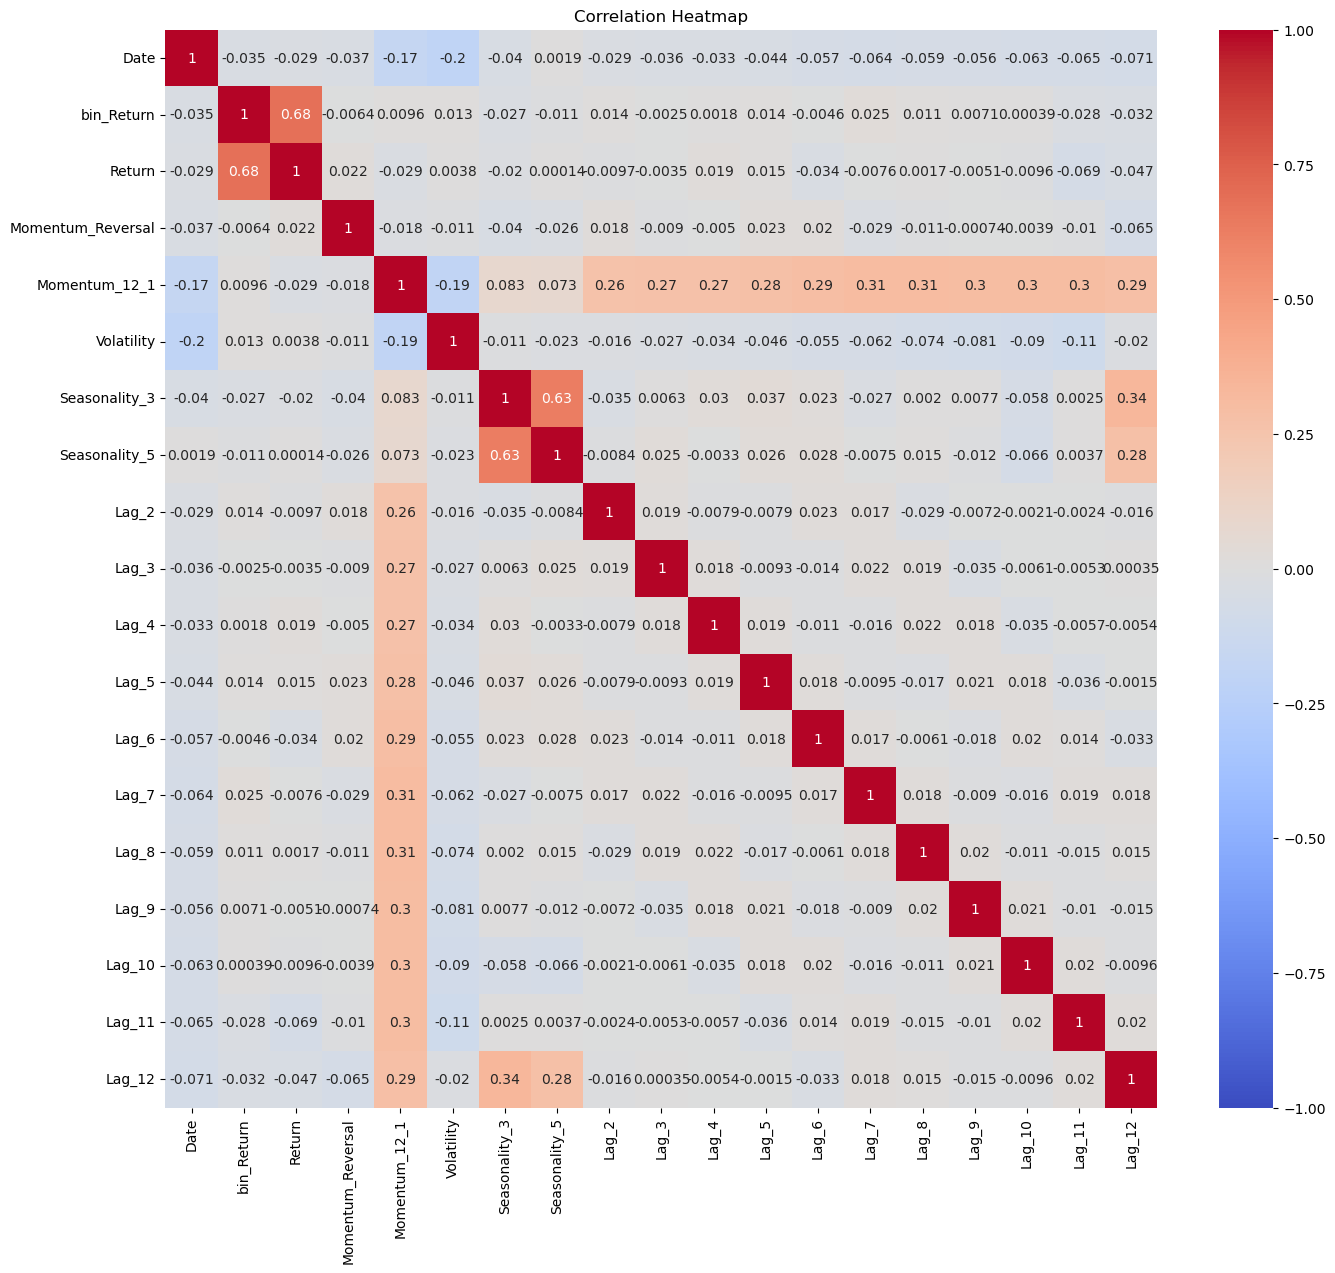

In [433]:
# Calculate correlation matrix
corr_matrix = filtered_df.corr()

# Plot heatmap
plt.figure(figsize=(16, 14))  # Adjust the figure size as needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

###### there is some corelation with 12-1 momentum but we will use xgboost that will handle multicolinearity.

# MODEL TRAINING

In [434]:
filtered_df.columns

Index(['Date', 'bin_Return', 'Return', 'Momentum_Reversal', 'Momentum_12_1',
       'Volatility', 'Seasonality_3', 'Seasonality_5', 'Lag_2', 'Lag_3',
       'Lag_4', 'Lag_5', 'Lag_6', 'Lag_7', 'Lag_8', 'Lag_9', 'Lag_10',
       'Lag_11', 'Lag_12'],
      dtype='object')

In [435]:
df1=filtered_df

In [436]:
#split_date = '2020-12-31'

# Split into training and testing data based on date
#train_df = df1[df1['Date'] <= split_date].reset_index(drop=True)
#test_df = df1[df1['Date'] > split_date].reset_index(drop=True)

split date= 2019-01-01

In [437]:
split_date = '2019-01-01'

# Split into training and testing data based on date
train_df = df1[df1['Date'] <= split_date].reset_index(drop=True)
test_df = df1[df1['Date'] > split_date].reset_index(drop=True)

In [438]:
train_df.shape,test_df.shape

((4737, 19), (810, 19))

In [439]:
# Features and target for training data
X_train = train_df.drop(columns=['Return', 'Date', 'bin_Return'])
y_train = train_df['bin_Return']
y_train_regn = train_df['Return']

# Features and target for testing data
X_test = test_df.drop(columns=['Return', 'Date', 'bin_Return'])
y_test = test_df['bin_Return']
y_test_regn = test_df['Return']

## fitting classification model

### RANDOM FOREST

In [440]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Base model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Hyperparameter grid
param_grid = {
    'n_estimators': [12800],
    'criterion': ['gini'],
    'max_depth': [7],
    'min_samples_split': [5],
    'min_samples_leaf': [5],
    'max_features': ['sqrt'],
    'bootstrap': [True],
    'class_weight': [None]
}


# GridSearch
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Train with CV
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True], 'class_weight': [None],
                         'criterion': ['gini'], 'max_depth': [7],
                         'max_features': ['sqrt'], 'min_samples_leaf': [5],
                         'min_samples_split': [5], 'n_estimators': [12800]},
             scoring='accuracy', verbose=1)

# Extract Best Model

In [441]:
best_rf = grid_search.best_estimator_

print("Best Hyperparameters:")
print(grid_search.best_params_)


Best Hyperparameters:
{'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 12800}


## Training & Test Accuracy

In [442]:
# Predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nTraining Accuracy (Best RF): {train_acc:.4f}")
print(f"Test Accuracy (Best RF): {test_acc:.4f}")



Training Accuracy (Best RF): 0.6610
Test Accuracy (Best RF): 0.5235


### Final Evaluation on Test Set

In [443]:
print("\nClassification Report (Best RF):")
print(classification_report(y_test, y_test_pred))



Classification Report (Best RF):
              precision    recall  f1-score   support

          -1       0.49      0.09      0.16       385
           1       0.53      0.91      0.67       425

    accuracy                           0.52       810
   macro avg       0.51      0.50      0.41       810
weighted avg       0.51      0.52      0.43       810



# XG BOOST

In [444]:
!pip install xgboost


In [445]:
# Convert labels for XGBoost
y_train_xgb = (y_train == 1).astype(int)
y_test_xgb  = (y_test == 1).astype(int)


In [446]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# --------------------------------------------------
# Base XGBoost model
# --------------------------------------------------
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

# --------------------------------------------------
# Hyperparameter grid
# (includes your exact configuration)
# --------------------------------------------------
param_grid_xgb = {
    'n_estimators': [12800],
    'max_depth': [7],
    'learning_rate': [ 0.03],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'min_child_weight': [10],
    'gamma': [0],
    'reg_alpha': [0],
    'reg_lambda': [1],
}


# --------------------------------------------------
# GridSearchCV (AUC is preferred in finance)
# --------------------------------------------------
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train
grid_xgb.fit(X_train, y_train_xgb)

# --------------------------------------------------
# Best model
# --------------------------------------------------
best_xgb = grid_xgb.best_estimator_

print("Best XGBoost Hyperparameters:")
print(grid_xgb.best_params_)

# --------------------------------------------------
# Predictions
# --------------------------------------------------
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

# --------------------------------------------------
# Accuracy (Train | Test)
# --------------------------------------------------
train_acc = accuracy_score(y_train_xgb, y_train_pred)
test_acc = accuracy_score(y_test_xgb, y_test_pred)

print(f"\nAccuracy (Test | Train): {test_acc:.8f}  {train_acc:.8f}")

# --------------------------------------------------
# Classification Report
# --------------------------------------------------
print("\nClassification Report (Best XGBoost):")
print(classification_report(y_test_xgb, y_test_pred))

# --------------------------------------------------
# ROC–AUC Score (VERY IMPORTANT in finance)
# --------------------------------------------------
auc = roc_auc_score(
    y_test_xgb,
    best_xgb.predict_proba(X_test)[:, 1]
)

print("Test AUC:", round(auc, 6))


Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\Biswajit Kala\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:22:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Hyperparameters:
{'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.03, 'max_depth': 7, 'min_child_weight': 10, 'n_estimators': 12800, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.7}

Accuracy (Test | Train): 0.52222222  1.00000000

Classification Report (Best XGBoost):
              precision    recall  f1-score   support

           0       0.50      0.41      0.45       385
           1       0.54      0.63      0.58       425

    accuracy                           0.52       810
   macro avg       0.52      0.52      0.51       810
weighted avg       0.52      0.52      0.52       810

Test AUC: 0.51549


## buy dict on train... 

In [447]:
training_df2 =  pd.merge(train_df, merged_df1[['Date', 'Stock', 'Return']], 
                      on=['Date', 'Return'], how='inner')

### RANDOM FOREST

In [448]:
y = best_rf.predict(X_train)
# Initialize buy and sell dictionaries
buy_dict_rf_train = {}
sell_dict_rf_train = {}

# Classify stocks into buy and sell based on predictions
for idx, pred in enumerate(y):
    stock = training_df.iloc[idx]['Stock']
    date = training_df.iloc[idx]['Date']
    
    if pred == 1:
        if date in buy_dict_rf_train:
            buy_dict_rf_train[date].append(stock)
        else:
            buy_dict_rf_train[date] = [stock]
    else:
        if date in sell_dict_rf_train:
            sell_dict_rf_train[date].append(stock)
        else:
            sell_dict_rf_train[date] = [stock]

buy_sell_rf_train = long_only_portfolio_return(return_df_monthly, buy_dict_rf_train, 50)

## xgboost

In [449]:
y = best_xgb.predict(X_train)
# Initialize buy and sell dictionaries
buy_dict_xgb_train = {}
sell_dict_xgb_train = {}

# Classify stocks into buy and sell based on predictions
for idx, pred in enumerate(y):
    stock = training_df.iloc[idx]['Stock']
    date = training_df.iloc[idx]['Date']
    
    if pred == 1:
        if date in buy_dict_rf_train:
            buy_dict_rf_train[date].append(stock)
        else:
            buy_dict_rf_train[date] = [stock]
    else:
        if date in sell_dict_rf_train:
            sell_dict_rf_train[date].append(stock)
        else:
            sell_dict_rf_train[date] = [stock]

buy_sell_xgb_train = long_only_portfolio_return(return_df_monthly, buy_dict_xgb_train, 50)

# long only BASED ON TEST

In [450]:
testing_df = pd.merge(test_df, merged_df1[['Date', 'Stock', 'Return']], 
                      on=['Date', 'Return'], how='inner')

In [451]:
testing_df.drop(['bin_Return', 'Return'], axis=1, inplace=True)
testing_df.reset_index(drop=True, inplace=True)
testing_df.head(2)

,Date,Momentum_Reversal,Momentum_12_1,Volatility,Seasonality_3,Seasonality_5,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7,Lag_8,Lag_9,Lag_10,Lag_11,Lag_12,Stock
0,2019-01-31,2.880449,21.691926,6.657344,-1,-1,2.013448,9.391255,-4.863527,-5.767059,-5.439576,14.785084,-3.081286,8.567030,7.256337,0.237083,-0.935035,ASIANPAINT
1,2019-02-28,-0.523857,26.378886,6.727409,1,1,2.880449,2.013448,9.391255,-4.863527,-5.767059,-5.439576,14.785084,-3.081286,8.567030,7.256337,0.237083,ASIANPAINT


## random forest

In [452]:



# Predict class probabilities
probabilities = best_rf.predict_proba(X_test)
y_test_pred1 = best_rf.predict(X_test)


# Initialize buy and sell dictionaries
buy_dict_dt = {}
sell_dict_dt = {}

# Classify stocks into buy and sell based on predictions
for idx, pred in enumerate(y_test_pred1):
    stock = testing_df.iloc[idx]['Stock']
    date = testing_df.iloc[idx]['Date'].strftime('%Y-%m-%d')  # Convert to string
    prob = probabilities[idx][1]  # Probability of class 1 (Buy)

    if pred == 1:  # Buy
        if date in buy_dict_dt:
            buy_dict_dt[date].append((stock, prob))
        else:
            buy_dict_dt[date] = [(stock, prob)]
    else:  # Sell
        if date in sell_dict_dt:
            sell_dict_dt[date].append((stock, prob))
        else:
            sell_dict_dt[date] = [(stock, prob)]

# Sort each date's stocks by probability (descending order)
for date in buy_dict_dt:
    buy_dict_dt[date] = sorted(buy_dict_dt[date], key=lambda x: x[1], reverse=True)

for date in sell_dict_dt:
    sell_dict_dt[date] = sorted(sell_dict_dt[date], key=lambda x: x[1], reverse=True)

# Remove probabilities, keeping only the stock names
buy_dict_dt = {date: [stock for stock, _ in stocks] for date, stocks in buy_dict_dt.items()}
sell_dict_dt = {date: [stock for stock, _ in stocks] for date, stocks in sell_dict_dt.items()}

# Final output dictionary
output_data_rf = {
    'buy_dict': buy_dict_dt,
    'sell_dict': sell_dict_dt
}





In [453]:
buy_dict_rf_test=output_data_rf['buy_dict']

In [454]:
buy_dict_rf_test

{'2019-01-31': ['BPCL',
  'IOC',
  'HDFC',
  'ICICIBANK',
  'LT',
  'HDFCBANK',
  'SBIN',
  'SUNPHARMA',
  'ONGC',
  'GAIL',
  'INDUSINDBK',
  'ASIANPAINT',
  'M&M',
  'ITC',
  'SHREECEM',
  'MARUTI',
  'BRITANNIA',
  'KOTAKBANK',
  'TATAMOTORS',
  'NTPC',
  'TITAN',
  'RELIANCE',
  'HCLTECH',
  'WIPRO',
  'ULTRACEMCO',
  'GRASIM',
  'CIPLA',
  'EICHERMOT'],
 '2019-02-28': ['ICICIBANK',
  'TATAMOTORS',
  'SUNPHARMA',
  'SBIN',
  'DRREDDY',
  'CIPLA',
  'M&M',
  'GAIL',
  'HCLTECH',
  'GRASIM',
  'MARUTI',
  'EICHERMOT',
  'TCS',
  'IOC',
  'RELIANCE',
  'WIPRO',
  'LT',
  'ULTRACEMCO',
  'KOTAKBANK',
  'BRITANNIA',
  'NTPC',
  'ITC',
  'ONGC',
  'HDFCBANK',
  'HDFC',
  'TITAN',
  'ASIANPAINT'],
 '2019-03-31': ['BPCL',
  'TATAMOTORS',
  'SHREECEM',
  'IOC',
  'HCLTECH',
  'SBIN',
  'MARUTI',
  'TCS',
  'INDUSINDBK',
  'RELIANCE',
  'GAIL',
  'HDFC',
  'HDFCBANK',
  'WIPRO',
  'M&M',
  'LT',
  'ASIANPAINT',
  'ONGC',
  'CIPLA',
  'TITAN',
  'GRASIM',
  'EICHERMOT',
  'ULTRACEMCO',
  'KOT

#### equal weighted portfolio return

In [455]:
buy_dict_rf_test_return=long_only_portfolio_return(return_df_monthly, buy_dict_rf_test, 50)

## xg boost

In [456]:



# Predict class probabilities
probabilities = best_xgb.predict_proba(X_test)
y_test_pred2 = best_xgb.predict(X_test)


# Initialize buy and sell dictionaries
buy_dict_dt = {}
sell_dict_dt = {}

# Classify stocks into buy and sell based on predictions
for idx, pred in enumerate(y_test_pred2):
    stock = testing_df.iloc[idx]['Stock']
    date = testing_df.iloc[idx]['Date'].strftime('%Y-%m-%d')  # Convert to string
    prob = probabilities[idx][1]  # Probability of class 1 (Buy)

    if pred == 1:  # Buy
        if date in buy_dict_dt:
            buy_dict_dt[date].append((stock, prob))
        else:
            buy_dict_dt[date] = [(stock, prob)]
    else:  # Sell
        if date in sell_dict_dt:
            sell_dict_dt[date].append((stock, prob))
        else:
            sell_dict_dt[date] = [(stock, prob)]

# Sort each date's stocks by probability (descending order)
for date in buy_dict_dt:
    buy_dict_dt[date] = sorted(buy_dict_dt[date], key=lambda x: x[1], reverse=True)

for date in sell_dict_dt:
    sell_dict_dt[date] = sorted(sell_dict_dt[date], key=lambda x: x[1], reverse=True)

# Remove probabilities, keeping only the stock names
buy_dict_dt = {date: [stock for stock, _ in stocks] for date, stocks in buy_dict_dt.items()}
sell_dict_dt = {date: [stock for stock, _ in stocks] for date, stocks in sell_dict_dt.items()}

# Final output dictionary
output_data_xgb = {
    'buy_dict': buy_dict_dt,
    'sell_dict': sell_dict_dt
}





In [457]:
buy_dict_xgb_test=output_data_xgb['buy_dict']

In [458]:
buy_dict_xgb_test

{'2019-01-31': ['KOTAKBANK',
  'BPCL',
  'INDUSINDBK',
  'BRITANNIA',
  'ITC',
  'ICICIBANK',
  'EICHERMOT',
  'IOC',
  'HDFC',
  'SBIN',
  'CIPLA',
  'ASIANPAINT'],
 '2019-02-28': ['TATAMOTORS',
  'RELIANCE',
  'SUNPHARMA',
  'TITAN',
  'HCLTECH',
  'ULTRACEMCO',
  'CIPLA',
  'M&M',
  'GRASIM',
  'HDFCBANK',
  'BRITANNIA',
  'SBIN',
  'MARUTI',
  'WIPRO',
  'EICHERMOT',
  'ASIANPAINT',
  'TCS'],
 '2019-03-31': ['TATAMOTORS',
  'BPCL',
  'TCS',
  'MARUTI',
  'HCLTECH',
  'NTPC',
  'DRREDDY',
  'INDUSINDBK',
  'LT',
  'ASIANPAINT',
  'SHREECEM',
  'GRASIM',
  'HDFC',
  'HDFCBANK'],
 '2019-05-31': ['CIPLA',
  'INDUSINDBK',
  'ULTRACEMCO',
  'TATAMOTORS',
  'BRITANNIA',
  'MARUTI',
  'SUNPHARMA',
  'WIPRO',
  'DRREDDY',
  'M&M',
  'ASIANPAINT',
  'SBIN',
  'ONGC',
  'SHREECEM',
  'HCLTECH',
  'LT',
  'BPCL',
  'EICHERMOT',
  'ICICIBANK'],
 '2019-09-30': ['ASIANPAINT',
  'GRASIM',
  'NTPC',
  'SHREECEM',
  'SUNPHARMA',
  'ONGC',
  'M&M',
  'CIPLA',
  'IOC',
  'SBIN',
  'KOTAKBANK',
  'RELI

#### equal weighted poretfolio return

In [459]:
buy_dict_xgb_test_return=long_only_portfolio_return(return_df_monthly, buy_dict_xgb_test, 50)

## step by step cagr from equal weifhted portfolio

## Random Forest Strategy

Testing period

In [460]:
strategy_returns_series_rf = pd.Series(buy_dict_rf_test_return)
strategy_returns_series_rf.index = pd.to_datetime(strategy_returns_series_rf.index)
strategy_returns_series_rf = strategy_returns_series_rf.sort_index()


In [461]:
calculate_cagr(strategy_returns_series_rf, 'ME')

15.52

### sharpe ratio

In [462]:
sharpe_ratio(strategy_returns_series_rf,'ME')

0.71

## XGBOOST STRATEGY

In [463]:
strategy_returns_series_xgb = pd.Series(buy_dict_xgb_test_return)
strategy_returns_series_xgb.index = pd.to_datetime(strategy_returns_series_xgb.index)
strategy_returns_series_xgb = strategy_returns_series_xgb.sort_index()

### CAGR

In [464]:
calculate_cagr(strategy_returns_series_xgb, 'ME')

17.73

### sharpe_ratio

In [465]:
sharpe_ratio(strategy_returns_series_xgb,'ME')

0.76

# start applying markowitz

# RANDOM FOREST

COMPUTE BUY DICTIONARY STOCKS.. WITH THEIR CORRESPONDING PROBABILITY TO GIVE POSITIVE RETURN.

In [466]:
# Predict class probabilities
probabilities = best_rf.predict_proba(X_test)
y_test_pred1 = best_rf.predict(X_test)

# Initialize buy and sell dictionaries
buy_dict_dt = {}
sell_dict_dt = {}

# Classify stocks into buy and sell based on predictions
for idx, pred in enumerate(y_test_pred1):

    stock = testing_df.iloc[idx]['Stock']
    date = testing_df.iloc[idx]['Date'].strftime('%Y-%m-%d')
    prob = probabilities[idx][1]  # Probability of positive return

    if pred == 1:  # Buy
        if date not in buy_dict_dt:
            buy_dict_dt[date] = []
        buy_dict_dt[date].append((stock, prob))

    else:  # Sell
        if date not in sell_dict_dt:
            sell_dict_dt[date] = []
        sell_dict_dt[date].append((stock, prob))

# Sort each date's stocks by probability (descending)
for date in buy_dict_dt:
    buy_dict_dt[date] = sorted(
        buy_dict_dt[date],
        key=lambda x: x[1],
        reverse=True
    )

for date in sell_dict_dt:
    sell_dict_dt[date] = sorted(
        sell_dict_dt[date],
        key=lambda x: x[1],
        reverse=True
    )

# Final output dictionary (KEEP probabilities)
output_data_rf = {
    'buy_dict': buy_dict_dt,
    'sell_dict': sell_dict_dt
}


In [467]:
buy_dict_rf_probability=output_data_rf['buy_dict']

In [468]:
buy_dict_rf_probability['2021-01-31']

[('LT', 0.6859838375936055),
 ('GAIL', 0.6858402795249752),
 ('HCLTECH', 0.6841893390767698),
 ('MARUTI', 0.6789483852067789),
 ('GRASIM', 0.675396567930795),
 ('SUNPHARMA', 0.6718153863250275),
 ('EICHERMOT', 0.6716473004130512),
 ('CIPLA', 0.660236226167651),
 ('ONGC', 0.6567172813834649),
 ('DRREDDY', 0.6539883291104399),
 ('HDFC', 0.6486142388950756),
 ('ITC', 0.6400263546982525),
 ('M&M', 0.6377102007594908),
 ('WIPRO', 0.6314713009010929),
 ('ASIANPAINT', 0.6076522166008599),
 ('BRITANNIA', 0.6053204874748146),
 ('IOC', 0.6024188369912666),
 ('BPCL', 0.5997261678471053),
 ('RELIANCE', 0.5962222046804818),
 ('NTPC', 0.593260254260406),
 ('ULTRACEMCO', 0.5894839942420133),
 ('SHREECEM', 0.586052367859883),
 ('INDUSINDBK', 0.5830555510741875),
 ('TITAN', 0.5646769421821736),
 ('SBIN', 0.5620361351898829),
 ('ICICIBANK', 0.5589368989574279),
 ('HDFCBANK', 0.5512495071596759),
 ('TCS', 0.5457525553295918),
 ('TATAMOTORS', 0.5418015156784327),
 ('KOTAKBANK', 0.5350055987233326)]

## compute z score of return

In [469]:
alpha_dict_rf = compute_alpha_from_buy_dict(buy_dict_rf_probability)


In [470]:
alpha_dict_rf

{'2019-01-31': {'BPCL': 2.0,
  'IOC': 1.948865012293181,
  'HDFC': 1.245894256308769,
  'ICICIBANK': 1.0110154065901225,
  'LT': 0.9588821312965403,
  'HDFCBANK': 0.8894954746290076,
  'SBIN': 0.8205898653932404,
  'SUNPHARMA': 0.7062046442787022,
  'ONGC': 0.4898168320118399,
  'GAIL': 0.47393374235577534,
  'INDUSINDBK': 0.32273694326609875,
  'ASIANPAINT': 0.28315700117340253,
  'M&M': -0.022082390507206468,
  'ITC': -0.21637022145852147,
  'SHREECEM': -0.24544880040820358,
  'MARUTI': -0.2694161076220957,
  'BRITANNIA': -0.32415451268029893,
  'KOTAKBANK': -0.36065997200557315,
  'TATAMOTORS': -0.4211025867457428,
  'NTPC': -0.4822246275953265,
  'TITAN': -0.573823834747655,
  'RELIANCE': -0.6919770755145462,
  'HCLTECH': -0.931135136152801,
  'WIPRO': -1.0540129903342683,
  'ULTRACEMCO': -1.3291369763088838,
  'GRASIM': -1.3876405263284488,
  'CIPLA': -1.5266495223494743,
  'EICHERMOT': -1.55831126729071},
 '2019-02-28': {'ICICIBANK': 2.0,
  'TATAMOTORS': 1.7711020744590769,
  'SU

### compute markowitz mu

“Instead of using noisy historical average returns, we use the Random Forest’s predicted probability of positive return as a relative alpha signal. Cross-sectional z-scoring removes scale instability and allows mean–variance optimization to focus on diversification rather than return estimation.”


for the corresponding date ....  mu = np.array(list(alpha_dict_rf[date].values()))

## compute markowitz corelation and co variance.

In [471]:
cov_dict_rf, corr_dict_rf = compute_rolling_cov_corr(
    buy_dict_rf_probability,
    monthly_log_returns,
    lookback_months=36
)


In [472]:
corr_dict_rf['2021-01-31']

symbol,LT,GAIL,HCLTECH,MARUTI,GRASIM,SUNPHARMA,EICHERMOT,CIPLA,ONGC,DRREDDY,...,ULTRACEMCO,SHREECEM,INDUSINDBK,TITAN,SBIN,ICICIBANK,HDFCBANK,TCS,TATAMOTORS,KOTAKBANK
symbol,,,,,,,,,,,,,,,,,,,,,
LT,1.000000,0.530145,0.266068,0.683824,0.695721,0.183628,0.102022,0.023721,0.732610,-0.063532,...,0.650597,0.638912,0.720747,0.659623,0.685134,0.749250,0.353172,0.176056,0.550360,0.637130
GAIL,0.530145,1.000000,0.169864,0.517383,0.503119,0.179015,0.098506,0.269767,0.624214,0.078864,...,0.357035,0.393240,0.335929,0.487670,0.418393,0.452675,0.271664,0.040034,0.447573,0.260739
HCLTECH,0.266068,0.169864,1.000000,0.286962,0.352610,0.437497,0.085228,0.335280,0.238181,0.378073,...,0.393367,0.199952,0.260155,0.249865,0.122648,0.174588,0.130272,0.313643,0.184078,0.026398
MARUTI,0.683824,0.517383,0.286962,1.000000,0.632157,0.299007,0.046328,0.254588,0.580816,0.153410,...,0.653518,0.600669,0.693758,0.644263,0.478884,0.576435,0.316223,0.188966,0.610513,0.452275
GRASIM,0.695721,0.503119,0.352610,0.632157,1.000000,0.297626,0.090435,0.249167,0.636650,0.099167,...,0.786866,0.724289,0.625050,0.414833,0.501550,0.489346,0.356240,0.275990,0.693653,0.335116
SUNPHARMA,0.183628,0.179015,0.437497,0.299007,0.297626,1.000000,0.125817,0.731623,0.369126,0.534188,...,0.235459,0.130473,0.276635,0.028602,0.177131,0.314752,0.293722,0.362789,0.399154,0.021003
EICHERMOT,0.102022,0.098506,0.085228,0.046328,0.090435,0.125817,1.000000,0.111178,0.061374,0.191133,...,0.245462,0.285608,0.001592,0.056174,-0.014929,-0.065039,-0.047302,0.055960,-0.084715,0.060161
CIPLA,0.023721,0.269767,0.335280,0.254588,0.249167,0.731623,0.111178,1.000000,0.308231,0.572232,...,0.226384,0.037232,0.005192,-0.024545,-0.069770,0.050586,0.135137,0.475746,0.350944,-0.163873
ONGC,0.732610,0.624214,0.238181,0.580816,0.636650,0.369126,0.061374,0.308231,1.000000,0.007575,...,0.513543,0.539206,0.601918,0.500347,0.618325,0.649511,0.275896,0.157119,0.641657,0.467788


## solve Markowitz

In [473]:
risk_preferences = [0.1, 0.5, 1, 3, 5, 10]

weights_dict = {}

for date in alpha_dict_rf.keys():

    if date not in cov_dict_rf:
        continue

    weights_dict[date] = {}

    for gamma in risk_preferences:

        weights = solve_markowitz_osqp(
            alpha_dict=alpha_dict_rf[date],
            cov_matrix=cov_dict_rf[date],
            gamma=gamma,
            w_max=1
        )

        if weights is not None:
            weights_dict[date][gamma] = weights


In [474]:
print(weights_dict)


{'2019-01-31': {0.1: {'BPCL': 0.6950275067782898, 'IOC': 0.30497249322171016, 'HDFC': 3.265735894304176e-23, 'ICICIBANK': -2.685296429051713e-23, 'LT': 1.169106836028043e-22, 'HDFCBANK': -7.379945379088532e-23, 'SBIN': -1.3240017590712043e-22, 'SUNPHARMA': -1.3648190290259512e-22, 'ONGC': 8.124342553846885e-24, 'GAIL': -3.355108819127844e-23, 'INDUSINDBK': 1.0816506843533605e-22, 'ASIANPAINT': 8.297890006111445e-23, 'M&M': -1.5702927372108592e-23, 'ITC': 4.5105025798946064e-23, 'SHREECEM': -1.3803925738603692e-23, 'MARUTI': 2.1595730504446055e-22, 'BRITANNIA': -2.6677003410757683e-22, 'KOTAKBANK': -7.061727884785588e-24, 'TATAMOTORS': -2.004781571086317e-23, 'NTPC': -1.2833428791820502e-25, 'TITAN': -2.232130468486052e-22, 'RELIANCE': -4.746419934393798e-22, 'HCLTECH': -1.4226099188951937e-23, 'WIPRO': 2.0992637321040583e-22, 'ULTRACEMCO': -2.3157993990260883e-22, 'GRASIM': 1.224700940884647e-23, 'CIPLA': -2.8358210121589555e-23, 'EICHERMOT': 1.9571309718041688e-22}, 0.5: {'BPCL': 1.00

## For each gamma, compute a time series of monthly portfolio returns.

In [475]:
monthly_simple_returns = monthly_simple_returns.copy()
monthly_simple_returns.index = monthly_simple_returns.index.to_period('M')


In [476]:
portfolio_returns_random_forest = backtest_portfolio(weights_dict, monthly_simple_returns)


In [477]:
portfolio_returns_random_forest

{0.1: 2019-02-01    0.001377
 2019-03-01    0.143796
 2019-04-01    0.150725
 2019-05-01   -0.010885
 2019-06-01   -0.024426
 2019-07-01   -0.083083
 2019-08-01   -0.012103
 2019-09-01    0.006427
 2019-10-01    0.075114
 2019-11-01    0.037956
 2019-12-01   -0.026220
 2020-01-01    0.059618
 2020-02-01   -0.066966
 2020-03-01   -0.233549
 2020-04-01    0.320394
 2020-05-01    0.021100
 2020-06-01    0.002668
 2020-07-01    0.106417
 2020-08-01   -0.009165
 2020-09-01    0.001648
 2020-10-01   -0.029633
 2020-11-01    0.050415
 2020-12-01    0.101997
 2021-01-01    0.329424
 2021-02-01    0.071642
 2021-03-01   -0.065492
 2021-04-01    0.034785
 dtype: float64,
 0.5: 2019-02-01   -0.022869
 2019-03-01    0.143796
 2019-04-01    0.150725
 2019-05-01   -0.010883
 2019-06-01   -0.024426
 2019-07-01   -0.165796
 2019-08-01   -0.012103
 2019-09-01    0.006427
 2019-10-01    0.075114
 2019-11-01    0.037956
 2019-12-01   -0.026220
 2020-01-01    0.066973
 2020-02-01   -0.066966
 2020-03-01  

In [478]:
print(type(next(iter(monthly_simple_returns.index))))
print(type((pd.to_datetime(list(weights_dict.keys())[0])).to_period('M')))


<class 'pandas._libs.tslibs.period.Period'>
<class 'pandas._libs.tslibs.period.Period'>


In [479]:
portfolio_returns_random_forest[1.0].head(5)


2019-02-01   -0.022869
2019-03-01    0.143796
2019-04-01    0.150725
2019-05-01   -0.010885
2019-06-01   -0.024426
dtype: float64

## Compute metrics for all γ

In [480]:
performance_summary = []

for gamma, rets in portfolio_returns_random_forest.items():

    cagr = compute_cagr_m(rets)
    sharpe = compute_sharpe_m(rets)
    vol = rets.std() * np.sqrt(12)

    performance_summary.append({
        "gamma": gamma,
        "CAGR": cagr,
        "Sharpe": sharpe,
        "Annual Volatility": vol
    })

performance_df = pd.DataFrame(performance_summary)


In [481]:
performance_df

,gamma,CAGR,Sharpe,Annual Volatility
0,0.1,0.417695,1.077727,0.393412
1,0.5,0.353869,0.935223,0.410362
2,1.0,0.353869,0.935223,0.410362
3,3.0,0.353868,0.935221,0.410362
4,5.0,0.353868,0.935221,0.410362
5,10.0,0.353870,0.935225,0.410362


An equal-weighted portfolio can absolutely have higher CAGR and Sharpe than a Markowitz-optimized portfolio — especially when expected returns are noisy.

## applying MARKOWITZ in XGBOOST

COMPUTE BUY DICTIONARY STOCKS.. WITH THEIR CORRESPONDING PROBABILITY TO GIVE POSITIVE RETURN.

In [482]:
# Predict class probabilities
probabilities = best_xgb.predict_proba(X_test)
y_test_pred2 = best_xgb.predict(X_test)

# Initialize buy and sell dictionaries
buy_dict_dt = {}
sell_dict_dt = {}

# Classify stocks into buy and sell based on predictions
for idx, pred in enumerate(y_test_pred2):

    stock = testing_df.iloc[idx]['Stock']
    date = testing_df.iloc[idx]['Date'].strftime('%Y-%m-%d')
    prob = probabilities[idx][1]  # Probability of positive return

    if pred == 1:  # Buy
        if date not in buy_dict_dt:
            buy_dict_dt[date] = []
        buy_dict_dt[date].append((stock, prob))

    else:  # Sell
        if date not in sell_dict_dt:
            sell_dict_dt[date] = []
        sell_dict_dt[date].append((stock, prob))

# Sort each date's stocks by probability (descending)
for date in buy_dict_dt:
    buy_dict_dt[date] = sorted(
        buy_dict_dt[date],
        key=lambda x: x[1],
        reverse=True
    )

for date in sell_dict_dt:
    sell_dict_dt[date] = sorted(
        sell_dict_dt[date],
        key=lambda x: x[1],
        reverse=True
    )

# Final output dictionary (KEEP probabilities)
output_data_xgb = {
    'buy_dict': buy_dict_dt,
    'sell_dict': sell_dict_dt
}


In [483]:
buy_dict_xgb_probability=output_data_xgb['buy_dict']

# compute z score of return

In [484]:
alpha_dict_xgb = compute_alpha_from_buy_dict(buy_dict_xgb_probability)


In [485]:
alpha_dict_xgb

{'2019-01-31': {'KOTAKBANK': 1.2118315,
  'BPCL': 1.1188762,
  'INDUSINDBK': 1.0442683,
  'BRITANNIA': 0.7865848,
  'ITC': 0.6468881,
  'ICICIBANK': 0.3234838,
  'EICHERMOT': -0.18076879,
  'IOC': -0.21776934,
  'HDFC': -0.7415253,
  'SBIN': -1.1608591,
  'CIPLA': -1.2388752,
  'ASIANPAINT': -1.5921363},
 '2019-02-28': {'TATAMOTORS': 0.9434655,
  'RELIANCE': 0.91670895,
  'SUNPHARMA': 0.88130194,
  'TITAN': 0.8785065,
  'HCLTECH': 0.856903,
  'ULTRACEMCO': 0.7097073,
  'CIPLA': 0.6933294,
  'M&M': 0.6648876,
  'GRASIM': 0.44285527,
  'HDFCBANK': 0.15994135,
  'BRITANNIA': -0.09233608,
  'SBIN': -0.32109347,
  'MARUTI': -0.39861026,
  'WIPRO': -1.4975326,
  'EICHERMOT': -1.51516,
  'ASIANPAINT': -1.5942882,
  'TCS': -1.7285873},
 '2019-03-31': {'TATAMOTORS': 1.5969361,
  'BPCL': 1.4225498,
  'TCS': 1.136695,
  'MARUTI': 0.7999263,
  'HCLTECH': 0.7929339,
  'NTPC': 0.11836418,
  'DRREDDY': -0.011378253,
  'INDUSINDBK': -0.36448935,
  'LT': -0.45350727,
  'ASIANPAINT': -0.51669806,
  'SHR

### compute markowitz mu

“Instead of using noisy historical average returns, we use the Random Forest’s predicted probability of positive return as a relative alpha signal. Cross-sectional z-scoring removes scale instability and allows mean–variance optimization to focus on diversification rather than return estimation.”


for the corresponding date ....  mu = np.array(list(alpha_dict_xgb[date].values()))

## compute markowitz corelation and co variance.

In [486]:
cov_dict_xgb, corr_dict_xgb = compute_rolling_cov_corr(
    buy_dict_xgb_probability,
    monthly_log_returns,
    lookback_months=60
)


## solve Markowitz

In [487]:
risk_preferences = [0.1, 0.5, 1, 3, 5, 10]

weights_dict = {}

for date in alpha_dict_xgb.keys():

    if date not in cov_dict_xgb:
        continue

    weights_dict[date] = {}

    for gamma in risk_preferences:

        weights = solve_markowitz_osqp(
            alpha_dict=alpha_dict_xgb[date],
            cov_matrix=cov_dict_xgb[date],
            gamma=gamma,
            w_max=1
        )

        if weights is not None:
            weights_dict[date][gamma] = weights


In [488]:
print(weights_dict)

{'2019-01-31': {0.1: {'KOTAKBANK': 0.954124642435034, 'BPCL': 0.04587535756496591, 'INDUSINDBK': 1.1425729955960312e-22, 'BRITANNIA': 6.374142329284928e-23, 'ITC': 2.4350323710820614e-23, 'ICICIBANK': 6.554908873142525e-23, 'EICHERMOT': 7.205028545797863e-24, 'IOC': 6.391309672029109e-23, 'HDFC': 9.241849216136864e-24, 'SBIN': 2.566179022745609e-22, 'CIPLA': -1.783112258718691e-22, 'ASIANPAINT': -6.236880491486017e-22}, 0.5: {'KOTAKBANK': 0.9999996156298175, 'BPCL': -5.052932173309053e-07, 'INDUSINDBK': -1.1550034754959034e-06, 'BRITANNIA': -5.153414492782068e-07, 'ITC': 1.2483116432283401e-06, 'ICICIBANK': -4.4496675841685586e-08, 'EICHERMOT': 6.892369271435902e-07, 'IOC': 8.071277273036957e-08, 'HDFC': 1.1080746414419566e-06, 'SBIN': 1.7612591822778317e-08, 'CIPLA': -1.7706229846622493e-07, 'ASIANPAINT': -3.623692523804935e-07}, 1: {'KOTAKBANK': 0.999999741471776, 'BPCL': -1.3005490323217112e-06, 'INDUSINDBK': -2.1345243723742424e-06, 'BRITANNIA': -9.80831936456914e-07, 'ITC': 2.2548

## For each gamma, compute a time series of monthly portfolio returns.

In [489]:
monthly_simple_returns = monthly_simple_returns.copy()
#monthly_simple_returns.index = monthly_simple_returns.index.to_period('M')


In [490]:
portfolio_returns_xg_boost = backtest_portfolio(weights_dict, monthly_simple_returns)


In [491]:
print(type(next(iter(monthly_simple_returns.index))))
print(type((pd.to_datetime(list(weights_dict.keys())[0])).to_period('M')))


<class 'pandas._libs.tslibs.period.Period'>
<class 'pandas._libs.tslibs.period.Period'>


In [492]:
portfolio_returns_xg_boost[1.0].head(5)


2019-02-01   -0.033964
2019-03-01   -0.018033
2019-04-01    0.229842
2019-05-01   -0.028226
2019-06-01   -0.009663
dtype: float64

## compute metric for all gamma

In [493]:
performance_summary = []

for gamma, rets in portfolio_returns_xg_boost.items():

    cagr = compute_cagr_m(rets)
    sharpe = compute_sharpe_m(rets)
    vol = rets.std() * np.sqrt(12)

    performance_summary.append({
        "gamma": gamma,
        "CAGR": cagr,
        "Sharpe": sharpe,
        "Annual Volatility": vol
    })

performance_df = pd.DataFrame(performance_summary)


In [494]:
performance_df

,gamma,CAGR,Sharpe,Annual Volatility
0,0.1,0.106419,0.457241,0.338599
1,0.5,0.118677,0.475327,0.360465
2,1.0,0.141193,0.526278,0.369355
3,3.0,0.160326,0.563694,0.383148
4,5.0,0.150296,0.535687,0.394828
5,10.0,0.136140,0.503181,0.399517


## now i will compute the risk ,CAGR and SR of equal weighted portfolio in the same period

### constracting buy dictionary

In [495]:
buy_dict_equal_weighted={}

for key in buy_dict_rf_test.keys():
    buy_dict_equal_weighted[key]=stocklist_16 # all the tickers of nifty 30 stocks which have atleast 16 years of data available in the csv file we imported


### compute long_only portfolio return

In [496]:
buy_dict_equal_weighted_return=long_only_portfolio_return(return_df_monthly, buy_dict_equal_weighted, 50)

### calculating CAGR AND SR

In [497]:
buy_dict_equal_weighted_return_series = pd.Series(buy_dict_equal_weighted_return)
buy_dict_equal_weighted_return_series.index = pd.to_datetime(buy_dict_equal_weighted_return_series.index)
buy_dict_equal_weighted_return_series = buy_dict_equal_weighted_return_series.sort_index()


### CAGR

In [498]:
calculate_cagr(buy_dict_equal_weighted_return_series,'ME')

14.66

### SR

In [499]:
sharpe_ratio(buy_dict_equal_weighted_return_series,'ME')

0.68

### Calculate risk

In [500]:
compute_portfolio_risk(buy_dict_equal_weighted_return_series, 12)


{'Annualized Mean Return': 16.75283062046271,
 'Annualized Volatility (Risk)': 24.495613807188658,
 'Sharpe Ratio': 0.6839114444050511,
 'Maximum Drawdown': -547.5063507749118}

### applying markowitz.. to the all nifty50... in time period january 2019-01-01 to december 2021-04-30

nse_stock_data.index = pd.to_datetime(nse_stock_data.index)

# 1. Rebalance at month-end (take month-end prices) not percentage in fraction
monthly_adj_close = nse_stock_data.resample('M').last()

# 2. Compute Percentage Return
return_df_monthly=additional.calculate_returns(nse_stock_data,rebalance='ME', periods=1)#"M"  # month-end, "MS"  # month-start, "BM"  # business month-end, "BMS"  # business month-start


# 3. Compute log returns
monthly_log_returns = np.log(monthly_adj_close / monthly_adj_close.shift(1))

# 4. Simple returns
monthly_simple_returns = (
    (monthly_adj_close / monthly_adj_close.shift(1)) - 1
)



### monthly_log_returns_full_50 it is the return dict of all 30 stocks.

In [501]:
monthly_log_returns_full_50.index = (
    monthly_log_returns_full_50.index.to_period('M')
)


In [502]:
monthly_simple_returns_full_50.index = (
    monthly_simple_returns_full_50.index.to_period('M')
)

In [503]:
gammas = [0.1, 0.5, 1, 3, 5, 10]

mean_dict, cov_dict = compute_hist_mean_cov_log(
    buy_dict_equal_weighted,
    monthly_log_returns_full_50, 36
)

weights_dict_markowitz = {}

for date in mean_dict:
    weights_dict_markowitz[date] = {}

    for gamma in gammas:
        w = solve_markowitz_historical(
            mean_dict[date],
            cov_dict[date],
            gamma,
            w_max=1
        )

        if w is not None:
            weights_dict_markowitz[date][gamma] = w


After optimization, I post-process portfolio weights by clipping numerical negatives, renormalizing to ensure full investment, and removing zero-weight assets to make the weights compatible with backtesting and real trading constraints.

In [504]:
clean_weights_dict = {}

for date, gamma_dict in weights_dict_markowitz.items():
    clean_weights_dict[date] = {}

    for gamma, weights in gamma_dict.items():

        # Step 1: clip tiny negatives to zero
        cleaned = {}
        for stock, w in weights.items():
            if w > 1e-8:      # threshold for numerical noise
                cleaned[stock] = w

        # If nothing left, skip
        if len(cleaned) == 0:
            continue

        # Step 2: renormalize to sum to 1
        total_weight = sum(cleaned.values())
        for stock in cleaned:
            cleaned[stock] = cleaned[stock] / total_weight

        # Step 3: store cleaned weights
        clean_weights_dict[date][gamma] = cleaned


In [505]:
clean_weights_dict

{'2019-01-31': {0.1: {'BPCL': 3.4143997672564555e-08,
   'BRITANNIA': 0.02660795035257794,
   'DRREDDY': 0.06902752577316965,
   'GAIL': 9.269052292734373e-08,
   'HCLTECH': 0.09673897326089546,
   'HDFC': 3.1090352412851616e-08,
   'HDFCBANK': 0.5523146953370754,
   'ICICIBANK': 1.2881625984819e-07,
   'INDUSINDBK': 4.1409870028894534e-08,
   'KOTAKBANK': 6.625369038534245e-08,
   'MARUTI': 9.140389404422805e-08,
   'NTPC': 3.751938972059473e-08,
   'ONGC': 1.459920514155484e-07,
   'SBIN': 7.963339310641613e-08,
   'TITAN': 0.2553100092923372,
   'ULTRACEMCO': 1.0061569985827489e-08,
   'WIPRO': 8.69689528516749e-08},
  0.5: {'HDFCBANK': 0.06687544368324413, 'TITAN': 0.9331245563167558},
  1: {'ASIANPAINT': 2.4818914353134736e-06,
   'CIPLA': 1.8934544498007684e-07,
   'DRREDDY': 6.923101430272292e-07,
   'EICHERMOT': 6.273592523478519e-07,
   'GAIL': 8.301421195488132e-07,
   'HDFC': 7.487983260640886e-07,
   'INDUSINDBK': 1.1531423644648724e-06,
   'IOC': 1.0990293672524377e-06,
  

In [506]:
portfolio_returns_markowitz_benchmark = backtest_portfolio(
    clean_weights_dict,
    monthly_simple_returns_full_50
)


In [507]:
print(
    len(weights_dict_markowitz),
    type(monthly_simple_returns_full_50.index),
    list(monthly_simple_returns_full_50.index)[:3]
)


27 <class 'pandas.core.indexes.period.PeriodIndex'> [Period('2000-01', 'M'), Period('2000-02', 'M'), Period('2000-03', 'M')]


In [508]:
portfolio_returns_markowitz_benchmark

{0.1: 2019-02-01    0.008154
 2019-03-01    0.099625
 2019-04-01    0.013631
 2019-05-01    0.034829
 2019-06-01    0.019360
 2019-07-01   -0.106050
 2019-08-01    0.004005
 2019-09-01   -0.021312
 2019-10-01    0.019820
 2019-11-01   -0.038787
 2019-12-01   -0.122302
 2020-01-01    0.001142
 2020-02-01   -0.007728
 2020-03-01   -0.179571
 2020-04-01    0.100989
 2020-05-01   -0.030025
 2020-06-01    0.005364
 2020-07-01    0.078149
 2020-08-01    0.042642
 2020-09-01    0.113237
 2020-10-01    0.019436
 2020-11-01    0.020185
 2020-12-01    0.160087
 2021-01-01   -0.123846
 2021-02-01   -0.030481
 2021-03-01    0.065534
 2021-04-01    0.056957
 dtype: float64,
 0.5: 2019-02-01    0.027472
 2019-03-01    0.114161
 2019-04-01    0.014625
 2019-05-01    0.066635
 2019-06-01    0.080072
 2019-07-01   -0.208549
 2019-08-01    0.004881
 2019-09-01    0.151004
 2019-10-01    0.026500
 2019-11-01   -0.117410
 2019-12-01    0.028413
 2020-01-01    0.000256
 2020-02-01    0.038841
 2020-03-01  

In [509]:
results = []

for gamma, rets in portfolio_returns_markowitz_benchmark.items():

    rets = rets.dropna()

    results.append({
        "Gamma": gamma,
        "CAGR": compute_cagr_m(rets),
        "Sharpe": compute_sharpe_m(rets),
        "Annual Volatility": rets.std(ddof=1) * np.sqrt(12),
        "Max Drawdown": compute_portfolio_risk(rets)["Maximum Drawdown"]
    })

results_df = pd.DataFrame(results)
results_df


,Gamma,CAGR,Sharpe,Annual Volatility,Max Drawdown
0,0.1,0.056771,0.339361,0.265920,-0.384044
1,0.5,0.061546,0.350507,0.341898,-0.337818
2,1.0,0.034299,0.276401,0.349147,-0.325767
3,3.0,-0.006180,0.160822,0.345840,-0.333181
4,5.0,-0.018844,0.124414,0.347289,-0.333183
5,10.0,-0.012462,0.144473,0.350355,-0.333182


### same strategy on random forest and xg boost

In [510]:
gammas = [0.1, 0.5, 1, 3, 5, 10]

mean_dict, cov_dict = compute_hist_mean_cov_log(
    buy_dict_rf_test,
    monthly_log_returns_full_50, 36
)

weights_dict_markowitz = {}

for date in mean_dict:
    weights_dict_markowitz[date] = {}

    for gamma in gammas:
        w = solve_markowitz_historical(
            mean_dict[date],
            cov_dict[date],
            gamma,
            w_max=1
        )

        if w is not None:
            weights_dict_markowitz[date][gamma] = w


In [511]:
clean_weights_dict = {}

for date, gamma_dict in weights_dict_markowitz.items():
    clean_weights_dict[date] = {}

    for gamma, weights in gamma_dict.items():

        # Step 1: clip tiny negatives to zero
        cleaned = {}
        for stock, w in weights.items():
            if w > 1e-8:      # threshold for numerical noise
                cleaned[stock] = w

        # If nothing left, skip
        if len(cleaned) == 0:
            continue

        # Step 2: renormalize to sum to 1
        total_weight = sum(cleaned.values())
        for stock in cleaned:
            cleaned[stock] = cleaned[stock] / total_weight

        # Step 3: store cleaned weights
        clean_weights_dict[date][gamma] = cleaned


In [512]:
portfolio_returns_markowitz_rf = backtest_portfolio(
    clean_weights_dict,
    monthly_simple_returns_full_50
)


In [513]:
results = []

for gamma, rets in portfolio_returns_markowitz_rf.items():

    rets = rets.dropna()

    results.append({
        "Gamma": gamma,
        "CAGR": compute_cagr_m(rets),
        "Sharpe": compute_sharpe_m(rets),
        "Annual Volatility": rets.std(ddof=1) * np.sqrt(12),
        "Max Drawdown": compute_portfolio_risk(rets)["Maximum Drawdown"]
    })

results_df = pd.DataFrame(results)
results_df


,Gamma,CAGR,Sharpe,Annual Volatility,Max Drawdown
0,0.1,0.022437,0.213719,0.246893,-0.379210
1,0.5,0.034096,0.273545,0.331657,-0.331969
2,1.0,0.016934,0.225907,0.341412,-0.313278
3,3.0,-0.067224,-0.030591,0.337691,-0.362046
4,5.0,-0.095446,-0.121958,0.337036,-0.404655
5,10.0,-0.099045,-0.134376,0.336562,-0.409969


## xg boost

In [514]:
gammas = [0.1, 0.5, 1, 3, 5, 10]

mean_dict, cov_dict = compute_hist_mean_cov_log(
    buy_dict_xgb_test,
    monthly_log_returns_full_50, 36
)

weights_dict_markowitz = {}

for date in mean_dict:
    weights_dict_markowitz[date] = {}

    for gamma in gammas:
        w = solve_markowitz_historical(
            mean_dict[date],
            cov_dict[date],
            gamma,
            w_max=1
        )

        if w is not None:
            weights_dict_markowitz[date][gamma] = w


In [515]:
clean_weights_dict = {}

for date, gamma_dict in weights_dict_markowitz.items():
    clean_weights_dict[date] = {}

    for gamma, weights in gamma_dict.items():

        # Step 1: clip tiny negatives to zero
        cleaned = {}
        for stock, w in weights.items():
            if w > 1e-8:      # threshold for numerical noise
                cleaned[stock] = w

        # If nothing left, skip
        if len(cleaned) == 0:
            continue

        # Step 2: renormalize to sum to 1
        total_weight = sum(cleaned.values())
        for stock in cleaned:
            cleaned[stock] = cleaned[stock] / total_weight

        # Step 3: store cleaned weights
        clean_weights_dict[date][gamma] = cleaned


In [516]:
portfolio_returns_markowitz_xgb = backtest_portfolio(
    clean_weights_dict,
    monthly_simple_returns_full_50
)


In [517]:
portfolio_returns_markowitz_xgb

{0.1: 2019-02-01   -0.024419
 2019-03-01    0.099663
 2019-04-01    0.013548
 2019-05-01    0.034816
 2019-06-01   -0.020859
 2019-07-01   -0.052179
 2019-08-01    0.004003
 2019-09-01   -0.258941
 2019-10-01    0.009492
 2019-11-01    0.018007
 2019-12-01    0.041989
 2020-01-01    0.001153
 2020-02-01   -0.041348
 2020-03-01   -0.194299
 2020-04-01    0.096197
 2020-05-01   -0.024072
 2020-06-01    0.005364
 2020-07-01    0.041939
 2020-08-01    0.012168
 2020-09-01    0.078070
 2020-10-01    0.051567
 2020-11-01    0.076234
 2020-12-01    0.092712
 2021-01-01   -0.131719
 2021-02-01    0.019102
 2021-03-01    0.049401
 2021-04-01    0.055491
 dtype: float64,
 0.5: 2019-02-01   -0.029229
 2019-03-01    0.114140
 2019-04-01   -0.000625
 2019-05-01    0.066635
 2019-06-01   -0.008284
 2019-07-01   -0.062205
 2019-08-01    0.004878
 2019-09-01   -0.148572
 2019-10-01    0.026496
 2019-11-01    0.034795
 2019-12-01    0.044598
 2020-01-01    0.001023
 2020-02-01   -0.040566
 2020-03-01  

In [518]:
results = []

for gamma, rets in portfolio_returns_markowitz_xgb.items():

    rets = rets.dropna()

    results.append({
        "Gamma": gamma,
        "CAGR": compute_cagr_m(rets),
        "Sharpe": compute_sharpe_m(rets),
        "Annual Volatility": rets.std(ddof=1) * np.sqrt(12),
        "Max Drawdown": compute_portfolio_risk(rets)["Maximum Drawdown"]
    })

results_df = pd.DataFrame(results)
results_df


,Gamma,CAGR,Sharpe,Annual Volatility,Max Drawdown
0,0.1,-0.020924,0.081431,0.289708,-0.428243
1,0.5,-0.100076,-0.242734,0.272036,-0.380572
2,1.0,-0.014634,0.080815,0.260617,-0.310296
3,3.0,0.064535,0.365782,0.288715,-0.291214
4,5.0,0.071972,0.386856,0.296123,-0.291215
5,10.0,0.073917,0.393000,0.296220,-0.292765


## plots to compare

λ = 0.1



Pattern Discovery → Markowitz Benchmark, Lambda: 0.1



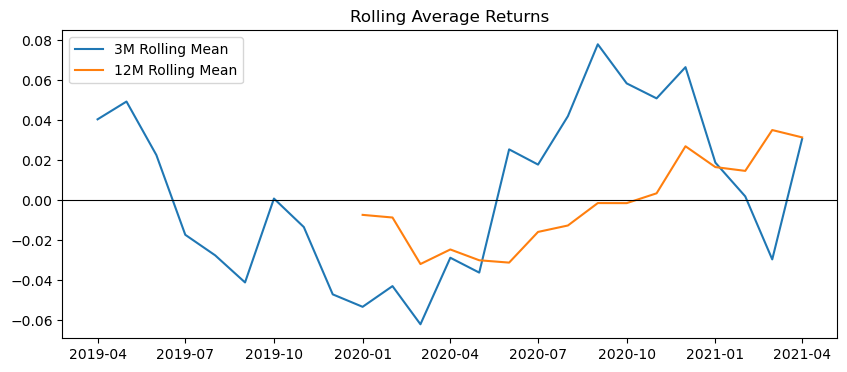

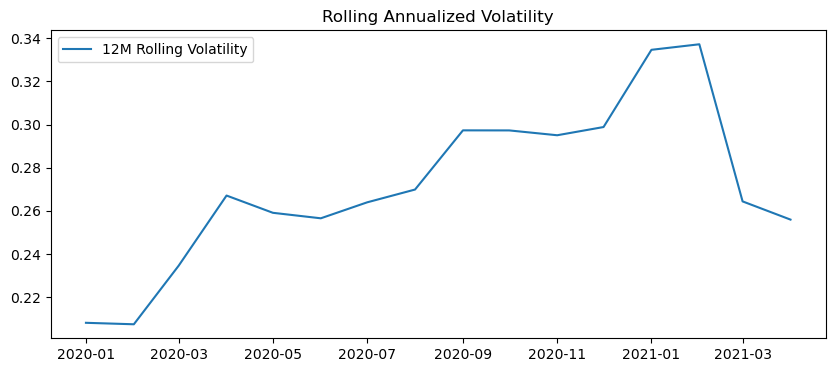

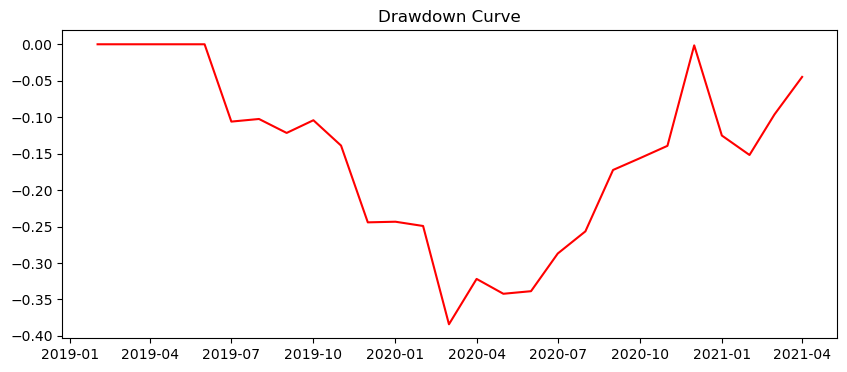

Max Drawdown : -38.40%
Trough Date  : 2020-03-01 00:00:00
Recovery Date: 2020-04-01 00:00:00

Regime-wise Performance:
          mean_return  volatility    sharpe
regime                                     
High Vol     0.037781    0.089523  1.461952
Low Vol     -0.005221    0.069403 -0.260606


In [519]:
run_pattern_discovery(
    portfolio_returns_markowitz_benchmark,
    portfolio_name="Markowitz Benchmark",
    lam=0.1
)



Pattern Discovery → Markowitz + Random Forest, Lambda: 0.1



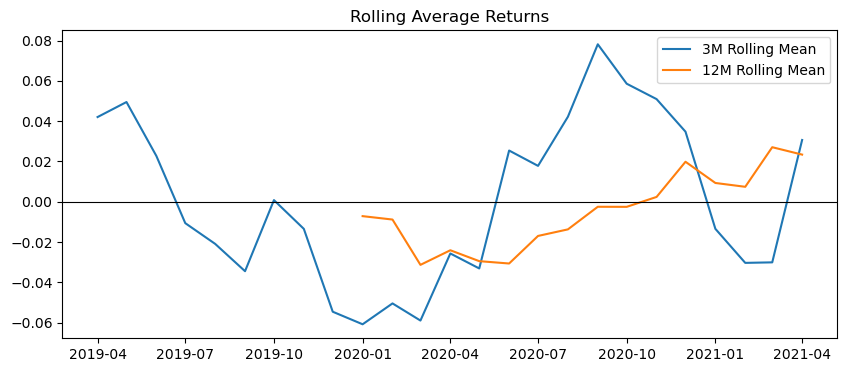

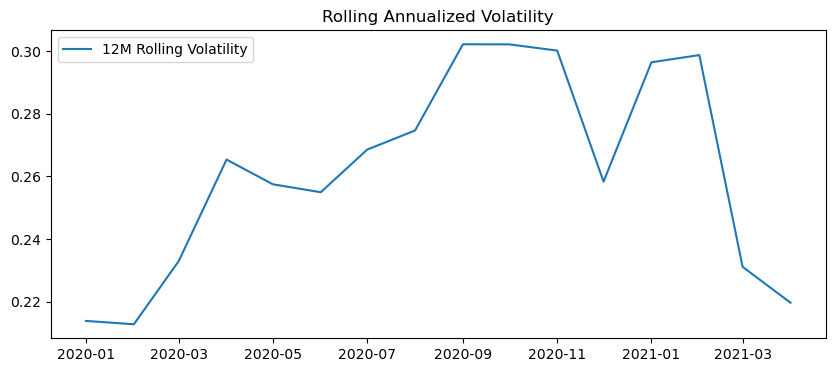

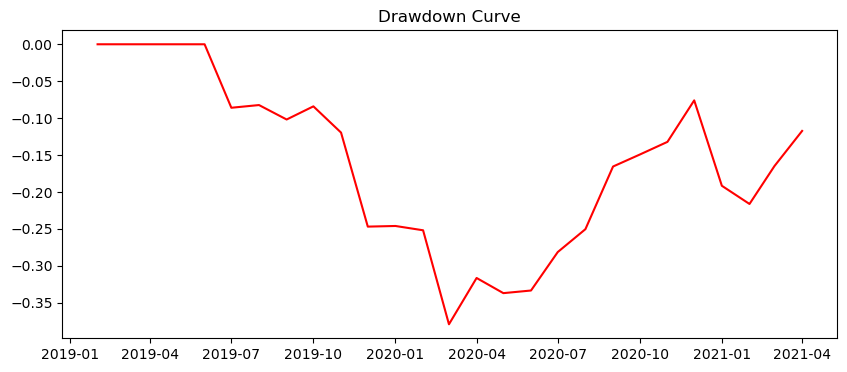

Max Drawdown : -37.92%
Trough Date  : 2020-03-01 00:00:00
Recovery Date: 2020-04-01 00:00:00

Regime-wise Performance:
          mean_return  volatility    sharpe
regime                                     
High Vol     0.027429    0.077781  1.221581
Low Vol     -0.005300    0.068188 -0.269269


In [520]:
run_pattern_discovery(
    portfolio_returns_markowitz_rf,
    portfolio_name="Markowitz + Random Forest",
    lam=0.1
)



Pattern Discovery → Markowitz + XGBoost, Lambda: 0.1



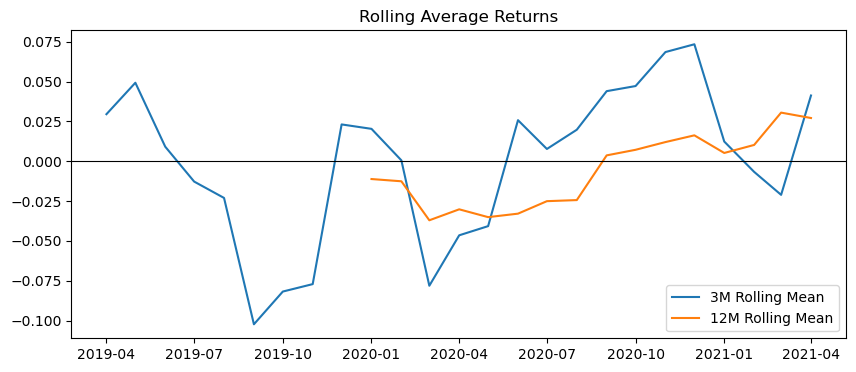

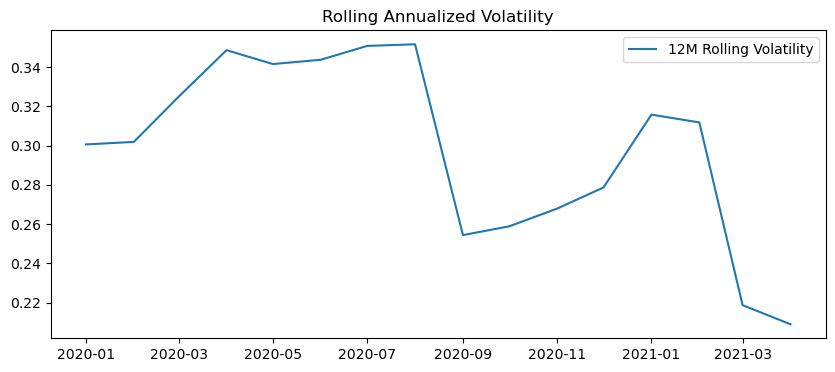

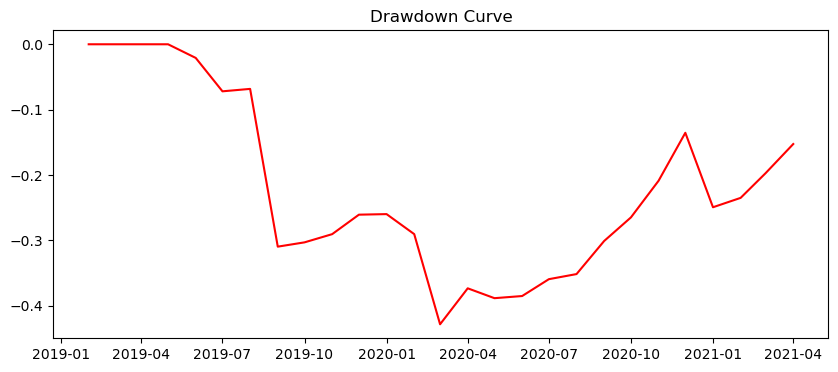

Max Drawdown : -42.82%
Trough Date  : 2020-03-01 00:00:00
Recovery Date: 2020-04-01 00:00:00

Regime-wise Performance:
          mean_return  volatility    sharpe
regime                                     
High Vol    -0.021915    0.095164 -0.797741
Low Vol      0.012021    0.078871  0.527978


In [521]:
run_pattern_discovery(
    portfolio_returns_markowitz_xgb,
    portfolio_name="Markowitz + XGBoost",
    lam=0.1
)


In [522]:
portfolio_returns = {
    "benchmark": portfolio_returns_markowitz_benchmark,
    "rf": portfolio_returns_markowitz_rf,
    "xgb": portfolio_returns_markowitz_xgb
}

In [523]:
lam=1

In [524]:
r_bm  = portfolio_returns["benchmark"][lam]
r_rf  = portfolio_returns["rf"][lam]
r_xgb = portfolio_returns["xgb"][lam]

# Align dates (important!)
returns_df = pd.concat(
    [r_bm, r_rf, r_xgb],
    axis=1,
    keys=["Benchmark", "Random Forest", "XGBoost"]
).dropna()


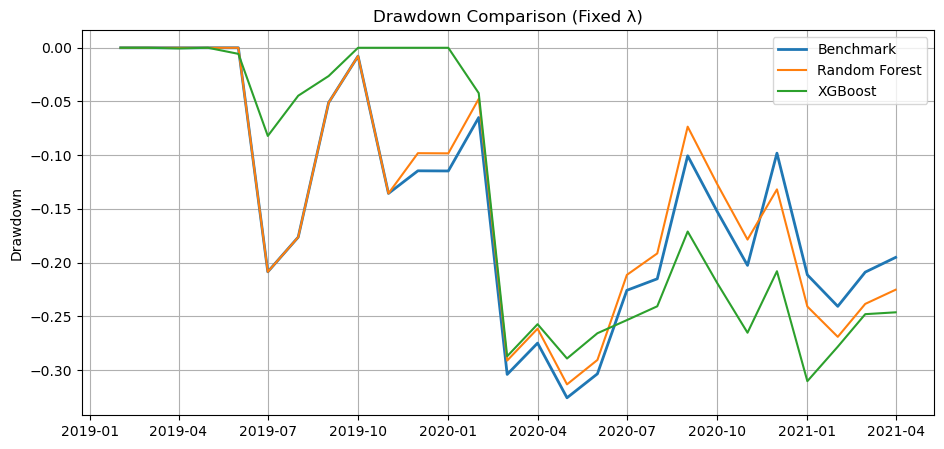

In [525]:
plot_drawdown_comparison(returns_df)


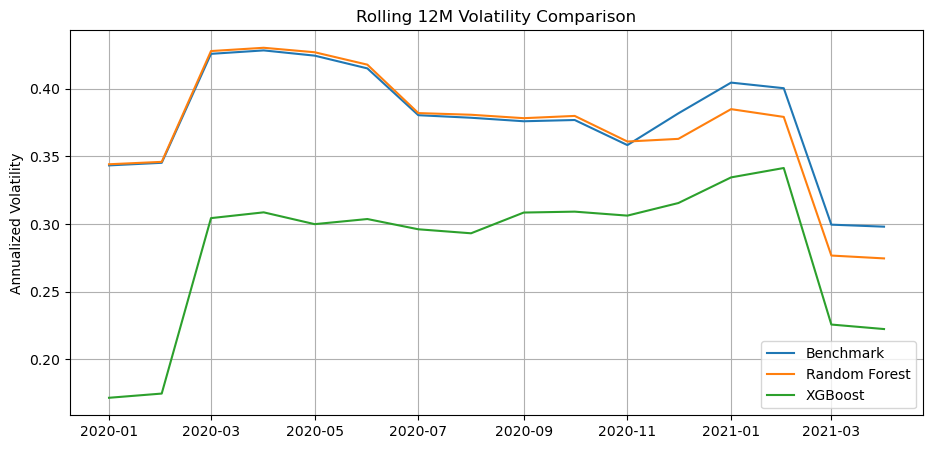

In [526]:
plot_volatility_comparison(returns_df)


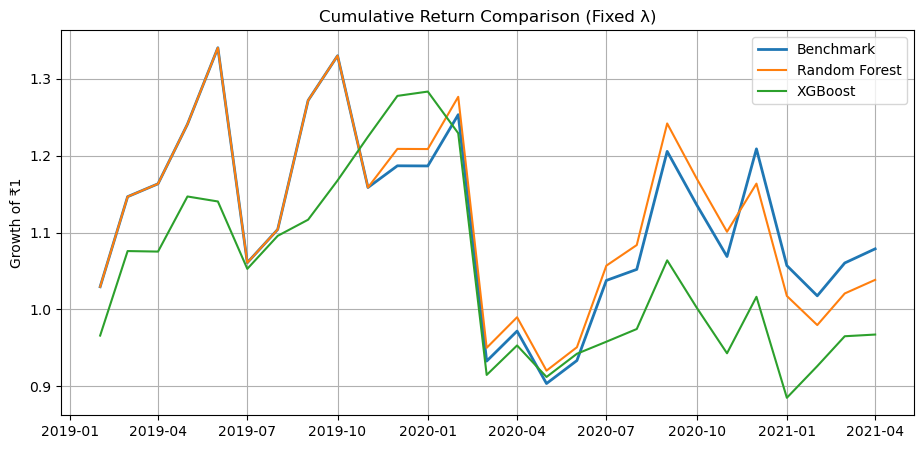

In [527]:
plot_cumulative_return_comparison(returns_df)
